## Section 0: Overview and Usage

This notebook implements four gate-by-gate simulations for the same validated JSON gate list:

- **Case A**: instantaneous ideal gates.
- **Case B**: pulse-level QuTiP dynamics with no dissipation.
- **Case C**: pulse-level QuTiP dynamics with dissipation from `T1`, `T2`, and optional cavity loss.
- **Case D**: pulse-level simulation with numerically calibrated SQR gates using cached or on-demand per-manifold optimization.

The diagnostic overlays compare **simulated pulse-level** outputs against **Case A ideal references** using stable conventions:

- Fock-resolved Bloch diagnostics use grouped bars by gate index.
- Same color = same Fock manifold `n`; simulated vs ideal are distinguished by filled vs hollow bar style.
- Relative phase uses masked segment-wise unwrapping and ratio-based phase error.
- Pulse-level trajectory overlays keep `X/Y/Z = blue/orange/green`, with simulated solid and ideal dashed.

Usage:

1. Edit the configuration in **Section 2**.
2. Run the notebook top-to-bottom.
3. Inspect the overlay diagnostics for Cases B/C/D in **Section Y**.
4. Review the weakness comparisons in **Section 8**.
5. Saved figures are written under `outputs/figures/`.

Note: the notebook intentionally omits the old test-suite and final-summary sections.


## Section 1: Imports and Environment Checks


In [1]:
from __future__ import annotations

import importlib
import importlib.metadata
from pathlib import Path

REQUIRED_HINTS = {
    "numpy": "pip install numpy",
    "matplotlib": "pip install matplotlib",
    "scipy": "pip install scipy",
    "qutip": "pip install qutip",
    "cqed_sim": "pip install -e .",
}

missing = []
versions = {}
for module_name, hint in REQUIRED_HINTS.items():
    try:
        module = importlib.import_module(module_name)
        versions[module_name] = getattr(module, "__version__", "unknown")
    except ModuleNotFoundError as exc:
        missing.append((module_name, hint, exc))

if missing:
    lines = ["Missing required notebook dependencies:"]
    for module_name, hint, exc in missing:
        lines.append(f"  - {module_name}: {exc}. Minimal install hint: {hint}")
    raise ModuleNotFoundError("\n".join(lines))

import matplotlib.pyplot as plt
import numpy as np
import qutip as qt
import scipy
from IPython.display import Markdown, display

from cqed_sim.io.gates import load_gate_sequence, render_gate_table
from cqed_sim.observables.fock import conditional_phase_diagnostics, fock_resolved_bloch_diagnostics, relative_phase_debug_values, relative_phase_family_diagnostics
from cqed_sim.observables.weakness import attach_weakness_metrics, comparison_metrics
from cqed_sim.plotting.bloch_plots import plot_bloch_track
from cqed_sim.plotting.gate_diagnostics import (
    plot_fock_resolved_bloch_grouped_bars,
    plot_gate_bloch_trajectory_error,
    plot_gate_bloch_trajectory_overlay,
    plot_phase_error_track,
    plot_phase_overlay_lines,
    save_figure,
)
from cqed_sim.plotting.phase_plots import plot_relative_phase_track
from cqed_sim.plotting.weakness_plots import (
    plot_cavity_population_comparison,
    plot_component_comparison,
    plot_weakness,
    print_mapping_rows,
)
from cqed_sim.plotting.wigner_grids import plot_wigner_grid
from cqed_sim.simulators.ideal import run_case_a
from cqed_sim.simulators.pulse_calibrated import run_case_d
from cqed_sim.simulators.pulse_open import run_case_c
from cqed_sim.simulators.pulse_unitary import run_case_b
from cqed_sim.simulators.trajectories import ideal_gate_bloch_trajectory, simulate_gate_bloch_trajectory

def package_version(dist_name: str, default: str = "editable/local") -> str:
    try:
        return importlib.metadata.version(dist_name)
    except importlib.metadata.PackageNotFoundError:
        return default

np.set_printoptions(precision=4, suppress=True)
print("Required versions:")
print(f"  numpy     : {versions['numpy']}")
print(f"  matplotlib: {versions['matplotlib']}")
print(f"  scipy     : {versions['scipy']}")
print(f"  qutip     : {versions['qutip']}")
print(f"  cqed_sim  : {package_version('cqed-sim')}")


Required versions:
  numpy     : 1.26.4
  matplotlib: 3.10.0
  scipy     : 1.17.0
  qutip     : 5.1.1
  cqed_sim  : 0.1.0


## Section 2: User Configuration


In [2]:
CONFIG = {
    "json_path": r"C:\Users\jl82323\Box\Shyam Shankar Quantum Circuits Group\Users\Users_JianJun\JJL_Experiments\decomposition\cluster_U_T_1-1e+03ns-3_sqr-no_phases",
    "json_fallback_path": "examples/sequences/sequential_demo.json",
    "cavity_fock_cutoff": 12,
    "initial_qubit": "g",
    "initial_cavity_kind": "fock",
    "initial_cavity_fock": 0,
    "initial_cavity_alpha": {"re": 0.0, "im": 0.0},
    "initial_cavity_amplitudes": None,
    "wigner_every_gate": True,
    "wigner_stride": 1,
    "wigner_points": 81,
    "wigner_extent": 4.0,
    "wigner_max_cols": 5,
    "top_axis_label_stride": 1,
    "summary_max_rows": 20,
    "phase_track_max_n": 2,
    "phase_reference_threshold": 1.0e-6,
    "phase_unwrap": True,
    "overlay_cases": ("Case B", "Case C", "Case D"),
    "trajectory_gate_index": None,
    "trajectory_conditioned_max_n": 2,
    "gate_diag_probability_threshold": 1.0e-6,
    "output_figure_dir": "outputs/figures",
    "save_output_figures": True,
    "output_figure_dpi": 160,
    "dt_s": 1.0e-9,
    "max_step_s": 1.0e-9,
    "duration_displacement_s": 48.0e-9,
    "duration_rotation_s": 16.0e-9,
    "duration_sqr_s": 1.0e-6,
    "rotation_sigma_fraction": 1.0 / 6.0,
    "sqr_sigma_fraction": 1.0 / 6.0,
    "sqr_theta_cutoff": 1.0e-10,
    "use_rotating_frame": True,
    "omega_c_hz": 0.0,
    "omega_q_hz": 0.0,
    "qubit_alpha_hz": 0.0,
    "st_chi_hz": -2840421.354241756,
    "st_chi2_hz": 0.0,
    "st_chi3_hz": 0.0,
    "st_K_hz": 0.0,
    "st_K2_hz": 0.0,
    "cavity_kappa_1_per_s": 0.0,
    "qb_T1_relax_ns": 98120.873848245112,
    "qb_T2_ramsey_ns": 63240.73112712837,
    "qb_T2_echo_ns": 80700.0,
    "t2_source": "ramsey",
    "max_n_cal": 2,
    "optimizer_method_stage1": "Powell",
    "optimizer_method_stage2": "L-BFGS-B",
    "optimizer_maxiter_stage1": 40,
    "optimizer_maxiter_stage2": 60,
    "d_lambda_bounds": (-0.5, 0.5),
    "d_alpha_bounds": (-np.pi, np.pi),
    "d_omega_hz_bounds": (-2.0e6, 2.0e6),
    "regularization_lambda": 1.0e-6,
    "regularization_alpha": 1.0e-6,
    "regularization_omega": 1.0e-18,
    "calibration_cache_dir": "calibrations",
    "calibration_force_recompute": False,
    "case_d_include_dissipation": True,
}
CONFIG["n_cav_dim"] = int(CONFIG["cavity_fock_cutoff"]) + 1

display(Markdown("Configured parameters:"))
for key in sorted(CONFIG):
    print(f"{key:>28}: {CONFIG[key]}")


Configured parameters:

       calibration_cache_dir: calibrations
 calibration_force_recompute: False
  case_d_include_dissipation: True
          cavity_fock_cutoff: 12
        cavity_kappa_1_per_s: 0.0
              d_alpha_bounds: (-3.141592653589793, 3.141592653589793)
             d_lambda_bounds: (-0.5, 0.5)
           d_omega_hz_bounds: (-2000000.0, 2000000.0)
                        dt_s: 1e-09
     duration_displacement_s: 4.8e-08
         duration_rotation_s: 1.6e-08
              duration_sqr_s: 1e-06
gate_diag_probability_threshold: 1e-06
        initial_cavity_alpha: {'re': 0.0, 'im': 0.0}
   initial_cavity_amplitudes: None
         initial_cavity_fock: 0
         initial_cavity_kind: fock
               initial_qubit: g
          json_fallback_path: examples/sequences/sequential_demo.json
                   json_path: C:\Users\jl82323\Box\Shyam Shankar Quantum Circuits Group\Users\Users_JianJun\JJL_Experiments\decomposition\cluster_U_T_1-1e+03ns-3_sqr-no_phases
                   max_n_cal: 2
 

## Section 3: Load and Validate JSON Gate List


In [3]:
requested_path = Path(CONFIG["json_path"])
fallback_path = Path(CONFIG["json_fallback_path"])
selected_path = CONFIG["json_path"] if requested_path.exists() else CONFIG["json_fallback_path"]
if not requested_path.exists():
    print("Configured JSON path was not found.")
    print(f"Requested: {requested_path}")
    print(f"Falling back to repo-local demo sequence: {fallback_path.resolve()}")

GATE_PATH, GATES = load_gate_sequence(selected_path)
print(f"Loaded {len(GATES)} gates from:\n  {GATE_PATH}")
render_gate_table(GATES, max_rows=int(CONFIG["summary_max_rows"]))


Loaded 10 gates from:
  C:\Users\jl82323\Box\Shyam Shankar Quantum Circuits Group\Users\Users_JianJun\JJL_Experiments\decomposition\cluster_U_T_1-1e+03ns-3_sqr-no_phases
  #  Type         Target   Name                                     Params
--------------------------------------------------------------------------
  0  Displacement storage  Disp_+0.382_-0.005                       alpha=+0.382-0.005j
  1  Rotation     qubit    Rotation_-2.2142823374858827_-1.56912986 theta=-2.214, phi=-1.569
  2  SQR          qubit    SQR_527e17733de113ecaead4876b2bcafeb     tones=12, active=1
  3  Displacement storage  Disp_-0.791_+0.004                       alpha=-0.791+0.004j
  4  Rotation     qubit    Rotation_-1.024328231656325_1.5603378419 theta=-1.024, phi=+1.560
  5  SQR          qubit    SQR_bc8194a85a260be4c0959c6c4d8d7ae1     tones=12, active=1
  6  Displacement storage  Disp_+0.763_-0.002                       alpha=+0.763-0.002j
  7  Rotation     qubit    Rotation_-1.2144143222850552_

## Section 4: Shared Operator Builders and Utilities


In [4]:
SHARED_API = [
    "run_case_a",
    "run_case_b",
    "run_case_c",
    "run_case_d",
    "fock_resolved_bloch_diagnostics",
    "conditional_phase_diagnostics",
    "relative_phase_debug_values",
    "relative_phase_family_diagnostics",
    "simulate_gate_bloch_trajectory",
    "ideal_gate_bloch_trajectory",
    "plot_fock_resolved_bloch_grouped_bars",
    "plot_phase_overlay_lines",
    "plot_phase_error_track",
    "plot_gate_bloch_trajectory_overlay",
    "plot_gate_bloch_trajectory_error",
]

print("Notebook orchestration uses cqed_sim package helpers:")
for name in SHARED_API:
    print(f"  - {name}")


Notebook orchestration uses cqed_sim package helpers:
  - run_case_a
  - run_case_b
  - run_case_c
  - run_case_d
  - fock_resolved_bloch_diagnostics
  - conditional_phase_diagnostics
  - relative_phase_debug_values
  - relative_phase_family_diagnostics
  - simulate_gate_bloch_trajectory
  - ideal_gate_bloch_trajectory
  - plot_fock_resolved_bloch_grouped_bars
  - plot_phase_overlay_lines
  - plot_phase_error_track
  - plot_gate_bloch_trajectory_overlay
  - plot_gate_bloch_trajectory_error


## Section 5: Case A --- Ideal Gate Simulation


Case A diagnostics:
{'solver': 'instantaneous_unitary', 'final_x': 0.005061829077818365, 'final_y': 0.0005559005790004138, 'final_z': 0.9995098045492445, 'final_n': 0.509575199653779}


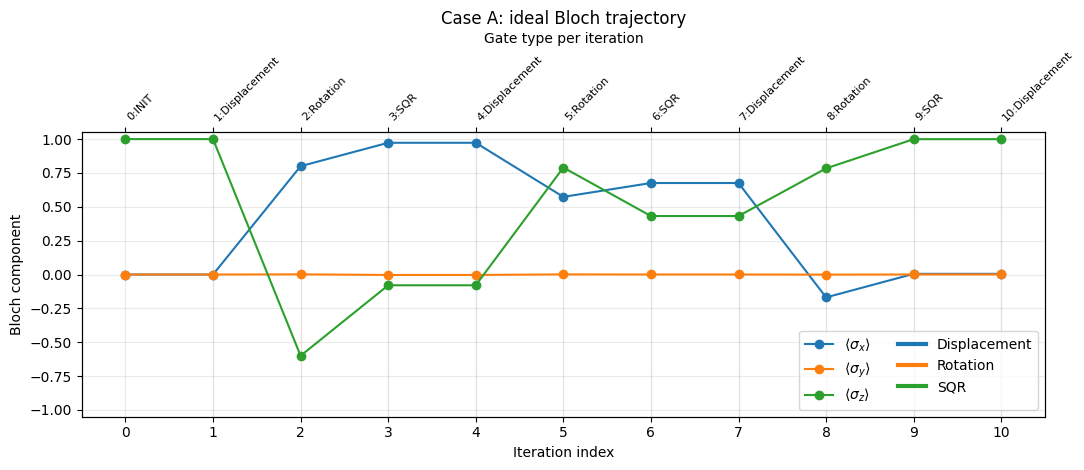

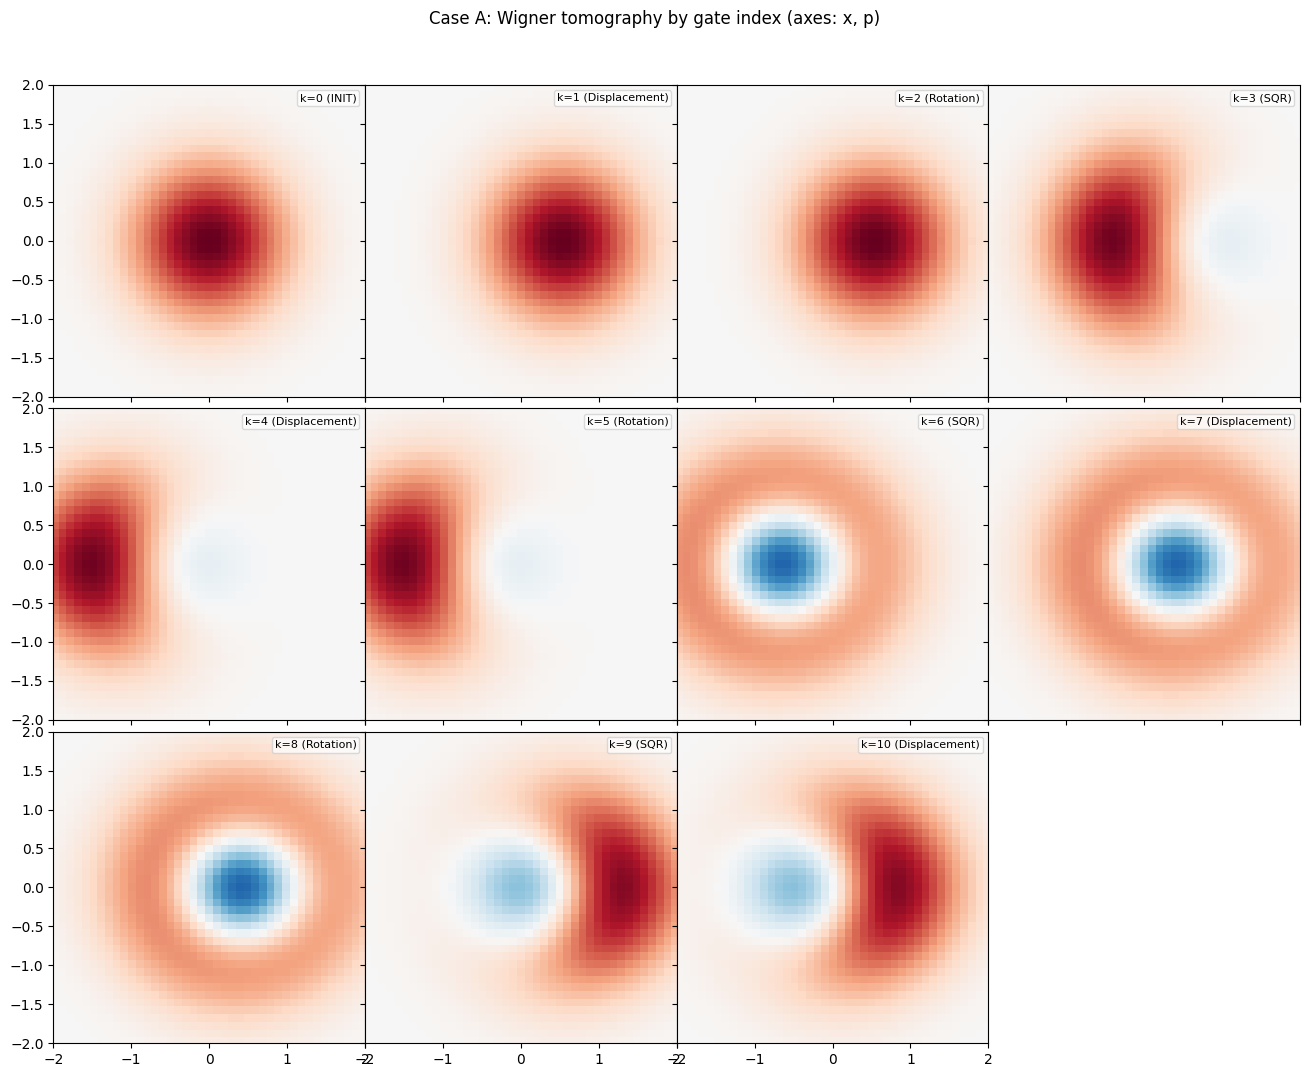

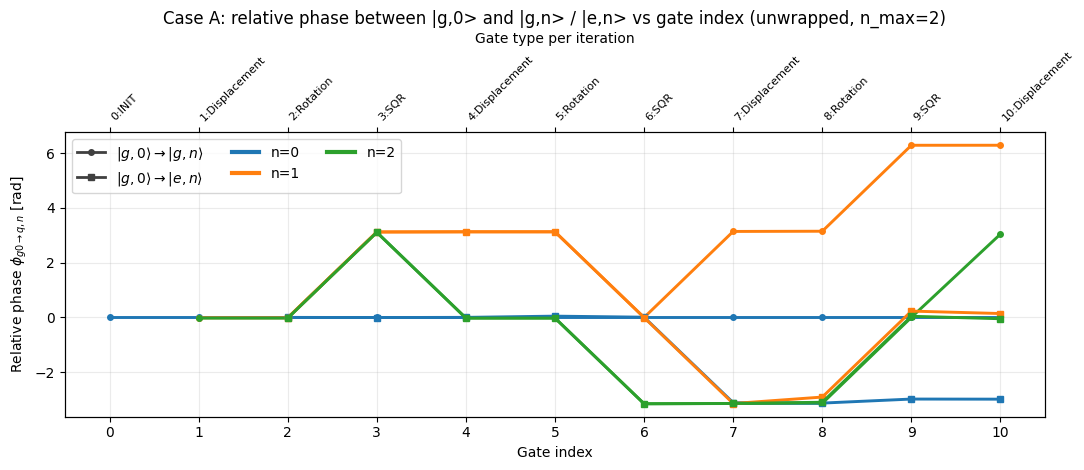

In [5]:
CASE_A = run_case_a(GATES, CONFIG, case_label="Case A")

print("Case A diagnostics:")
print(
    {
        "solver": CASE_A["metadata"]["solver"],
        "final_x": CASE_A["x"][-1],
        "final_y": CASE_A["y"][-1],
        "final_z": CASE_A["z"][-1],
        "final_n": CASE_A["n"][-1],
    }
)

plot_bloch_track(CASE_A, title="Case A: ideal Bloch trajectory", label_stride=int(CONFIG["top_axis_label_stride"]))
plt.show()

plot_wigner_grid(CASE_A, title="Case A: Wigner tomography by gate index", stride=int(CONFIG["wigner_stride"]), max_cols=int(CONFIG["wigner_max_cols"]))
plt.show()

plot_relative_phase_track(
    CASE_A,
    max_n=int(CONFIG["phase_track_max_n"]),
    threshold=float(CONFIG["phase_reference_threshold"]),
    unwrap=bool(CONFIG["phase_unwrap"]),
    label_stride=int(CONFIG["top_axis_label_stride"]),
)
plt.show()


## Section 6: Case B --- Pulse-level Simulation (No Dissipation)

SQR note:

`cqed_sim` provides dispersive manifold-frequency helpers, but not a fully hardware-calibrated selective-SQR compiler. Cases B and C therefore use a simplified multitone Gaussian rotating-wave model:

- one Gaussian-windowed tone per active Fock manifold,
- tone frequencies from `cqed_sim.snap_opt.model.manifold_transition_frequency(...)`,
- per-tone area calibration `theta_n ~= integral Omega_n(t) dt`.


Case B diagnostics:
{'solver': 'sesolve', 'final_x': -0.579407621751369, 'final_y': -0.7055939264929927, 'final_z': 0.37915468795074647, 'final_n': 0.5518790369451906}
Case B gate-to-pulse mapping:
k= 1 Displacement Square cavity drive with analytic rotating-frame calibration alpha = -i * integral epsilon(t) dt.
k= 2 Rotation     Gaussian qubit drive with analytic RWA calibration theta = 2 * integral Omega(t) dt.
k= 3 SQR          Simplified multitone Gaussian SQR using cqed_sim manifold_transition_frequency(...) and per-tone RWA area calibration.
k= 4 Displacement Square cavity drive with analytic rotating-frame calibration alpha = -i * integral epsilon(t) dt.
k= 5 Rotation     Gaussian qubit drive with analytic RWA calibration theta = 2 * integral Omega(t) dt.
k= 6 SQR          Simplified multitone Gaussian SQR using cqed_sim manifold_transition_frequency(...) and per-tone RWA area calibration.
k= 7 Displacement Square cavity drive with analytic rotating-frame calibration alpha = -i 

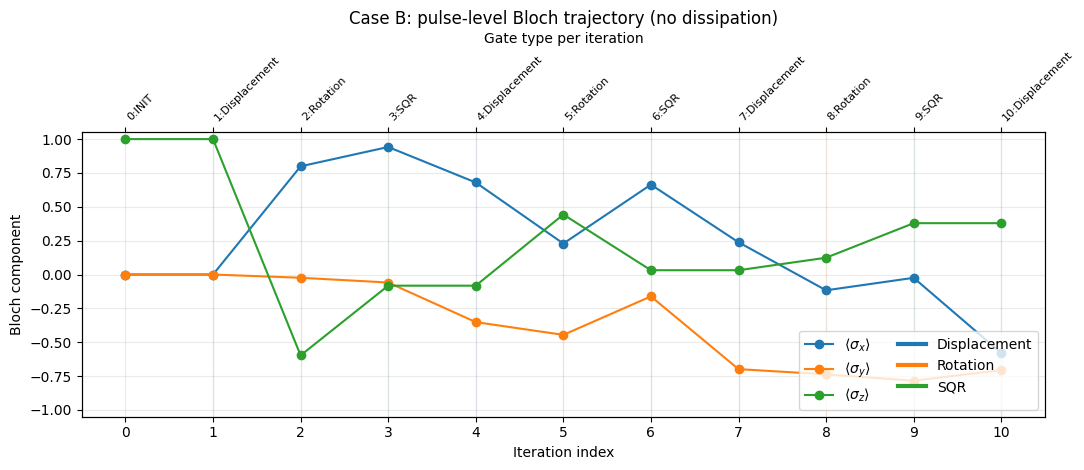

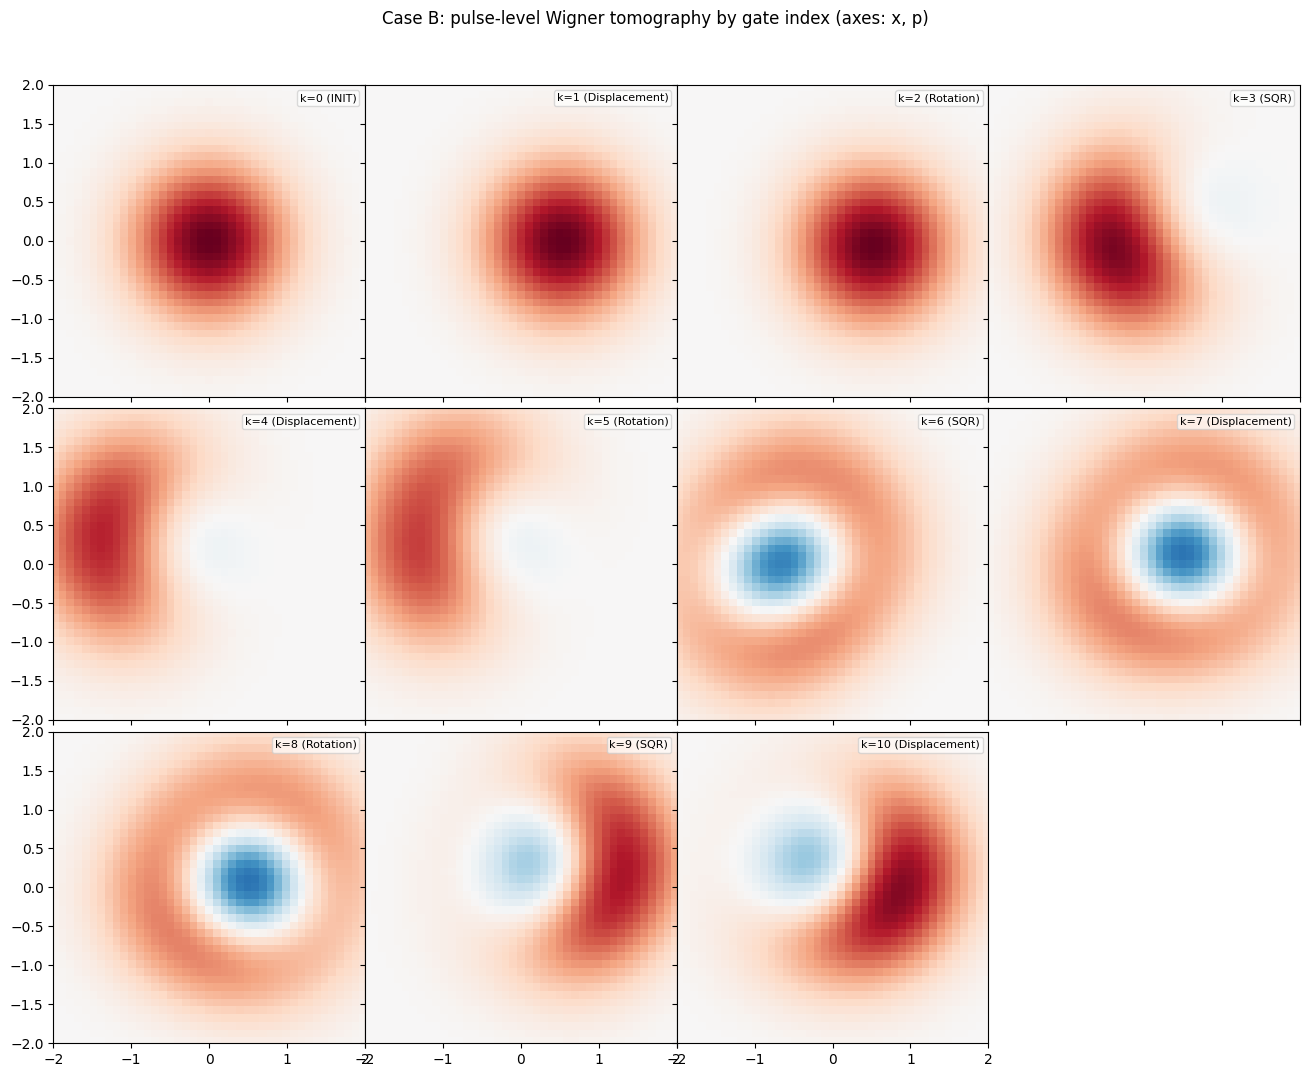

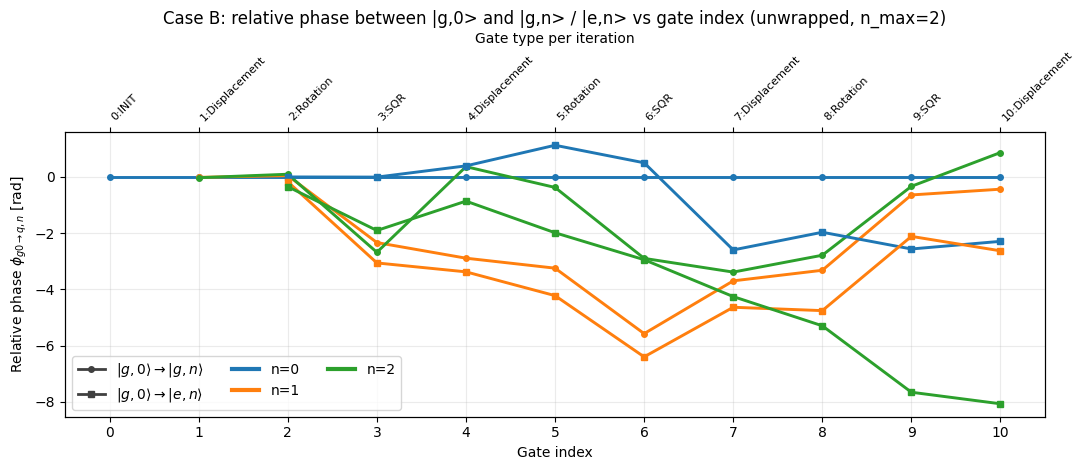

In [6]:
CASE_B = run_case_b(GATES, CONFIG, case_label="Case B")

print("Case B diagnostics:")
print(
    {
        "solver": CASE_B["metadata"]["solver"],
        "final_x": CASE_B["x"][-1],
        "final_y": CASE_B["y"][-1],
        "final_z": CASE_B["z"][-1],
        "final_n": CASE_B["n"][-1],
    }
)
print("Case B gate-to-pulse mapping:")
print_mapping_rows(CASE_B)

plot_bloch_track(CASE_B, title="Case B: pulse-level Bloch trajectory (no dissipation)", label_stride=int(CONFIG["top_axis_label_stride"]))
plt.show()

plot_wigner_grid(CASE_B, title="Case B: pulse-level Wigner tomography by gate index", stride=int(CONFIG["wigner_stride"]), max_cols=int(CONFIG["wigner_max_cols"]))
plt.show()

plot_relative_phase_track(
    CASE_B,
    max_n=int(CONFIG["phase_track_max_n"]),
    threshold=float(CONFIG["phase_reference_threshold"]),
    unwrap=bool(CONFIG["phase_unwrap"]),
    label_stride=int(CONFIG["top_axis_label_stride"]),
)
plt.show()


## Section 7: Case C --- Pulse-level Simulation (With Dissipation)


Case C diagnostics:
{'solver': 'mesolve', 'final_x': -0.561061718045465, 'final_y': -0.6694221672141798, 'final_z': 0.377574145148992, 'final_n': 0.5591211768720165}
{'t1_s': 9.812087384824512e-05, 'tphi_s': 9.331110334423099e-05, 'kappa_1_per_s': None, 'gamma1_1_per_s': 10191.51135513338, 'gamma_phi_prefactor_1_per_s': 5358.419117127638}
Case C gate-to-pulse mapping:
k= 1 Displacement Square cavity drive with analytic rotating-frame calibration alpha = -i * integral epsilon(t) dt.
k= 2 Rotation     Gaussian qubit drive with analytic RWA calibration theta = 2 * integral Omega(t) dt.
k= 3 SQR          Simplified multitone Gaussian SQR using cqed_sim manifold_transition_frequency(...) and per-tone RWA area calibration.
k= 4 Displacement Square cavity drive with analytic rotating-frame calibration alpha = -i * integral epsilon(t) dt.
k= 5 Rotation     Gaussian qubit drive with analytic RWA calibration theta = 2 * integral Omega(t) dt.
k= 6 SQR          Simplified multitone Gaussian SQR us

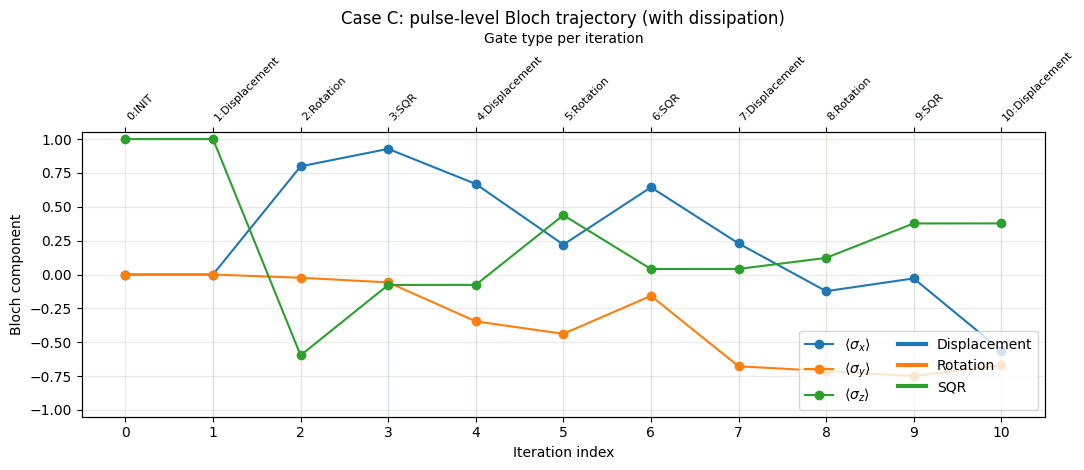

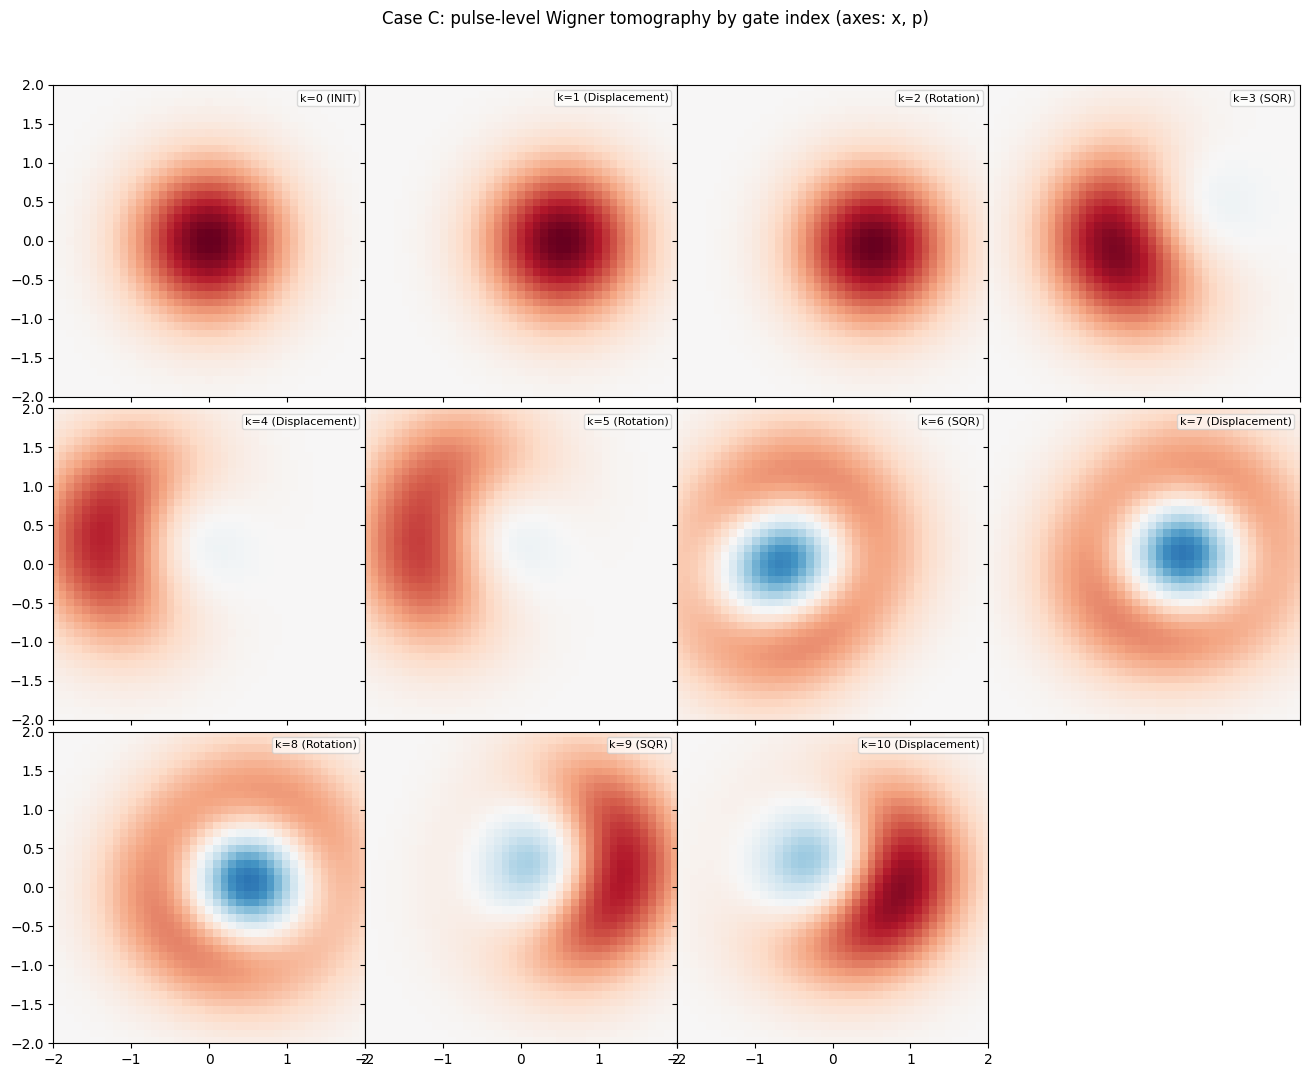

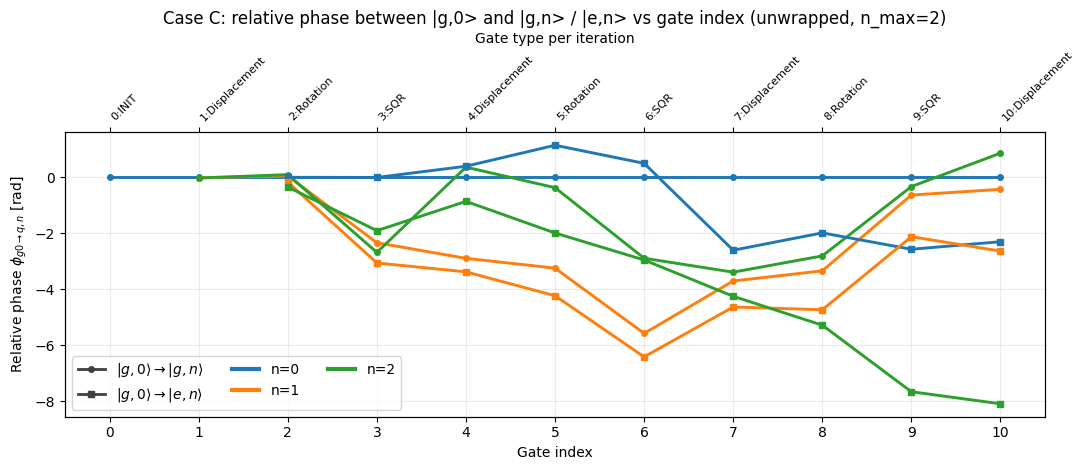

In [7]:
CASE_C = run_case_c(GATES, CONFIG, case_label="Case C")

print("Case C diagnostics:")
print(
    {
        "solver": CASE_C["metadata"]["solver"],
        "final_x": CASE_C["x"][-1],
        "final_y": CASE_C["y"][-1],
        "final_z": CASE_C["z"][-1],
        "final_n": CASE_C["n"][-1],
    }
)
noise = CASE_C["metadata"]["noise"]
print(
    {
        "t1_s": None if noise is None else noise.t1,
        "tphi_s": None if noise is None else noise.tphi,
        "kappa_1_per_s": None if noise is None else noise.kappa,
        "gamma1_1_per_s": None if noise is None else noise.gamma1,
        "gamma_phi_prefactor_1_per_s": None if noise is None else noise.gamma_phi,
    }
)
print("Case C gate-to-pulse mapping:")
print_mapping_rows(CASE_C)

plot_bloch_track(CASE_C, title="Case C: pulse-level Bloch trajectory (with dissipation)", label_stride=int(CONFIG["top_axis_label_stride"]))
plt.show()

plot_wigner_grid(CASE_C, title="Case C: pulse-level Wigner tomography by gate index", stride=int(CONFIG["wigner_stride"]), max_cols=int(CONFIG["wigner_max_cols"]))
plt.show()

plot_relative_phase_track(
    CASE_C,
    max_n=int(CONFIG["phase_track_max_n"]),
    threshold=float(CONFIG["phase_reference_threshold"]),
    unwrap=bool(CONFIG["phase_unwrap"]),
    label_stride=int(CONFIG["top_axis_label_stride"]),
)
plt.show()


## Section X: Case D --- Pulse-level Simulation with Calibrated SQR


Case D diagnostics:
{'solver': 'mesolve', 'final_x': -0.5610586245976854, 'final_y': -0.669420944446254, 'final_z': 0.37757940397237905, 'final_n': 0.5591162282674967, 'n_calibrated_sqr_gates': 3}
Case D gate-to-pulse mapping:
k= 1 Displacement Square cavity drive with analytic rotating-frame calibration alpha = -i * integral epsilon(t) dt.
k= 2 Rotation     Gaussian qubit drive with analytic RWA calibration theta = 2 * integral Omega(t) dt.
k= 3 SQR          Simplified multitone Gaussian SQR using cqed_sim manifold_transition_frequency(...) and per-tone RWA area calibration. Applied cached/numerically optimized per-manifold corrections to amplitude, phase, and tone frequency.
k= 4 Displacement Square cavity drive with analytic rotating-frame calibration alpha = -i * integral epsilon(t) dt.
k= 5 Rotation     Gaussian qubit drive with analytic RWA calibration theta = 2 * integral Omega(t) dt.
k= 6 SQR          Simplified multitone Gaussian SQR using cqed_sim manifold_transition_frequenc

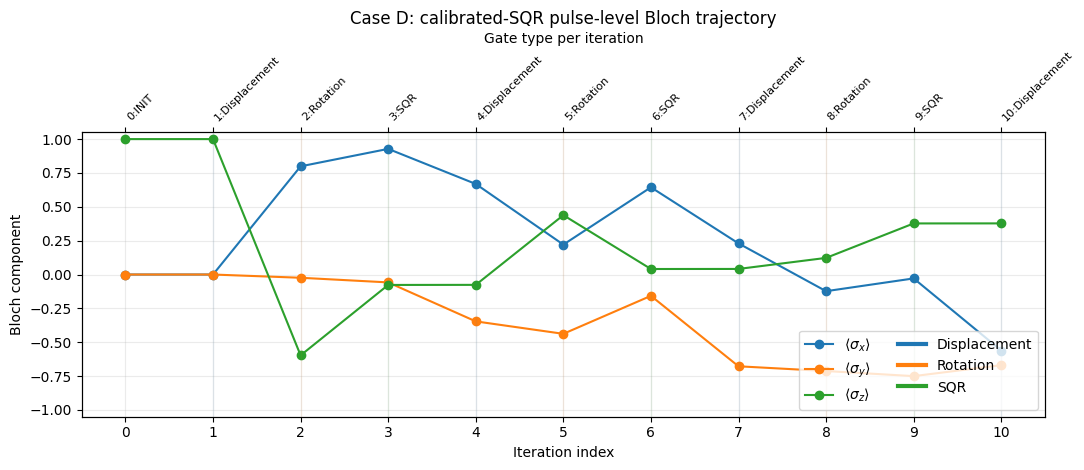

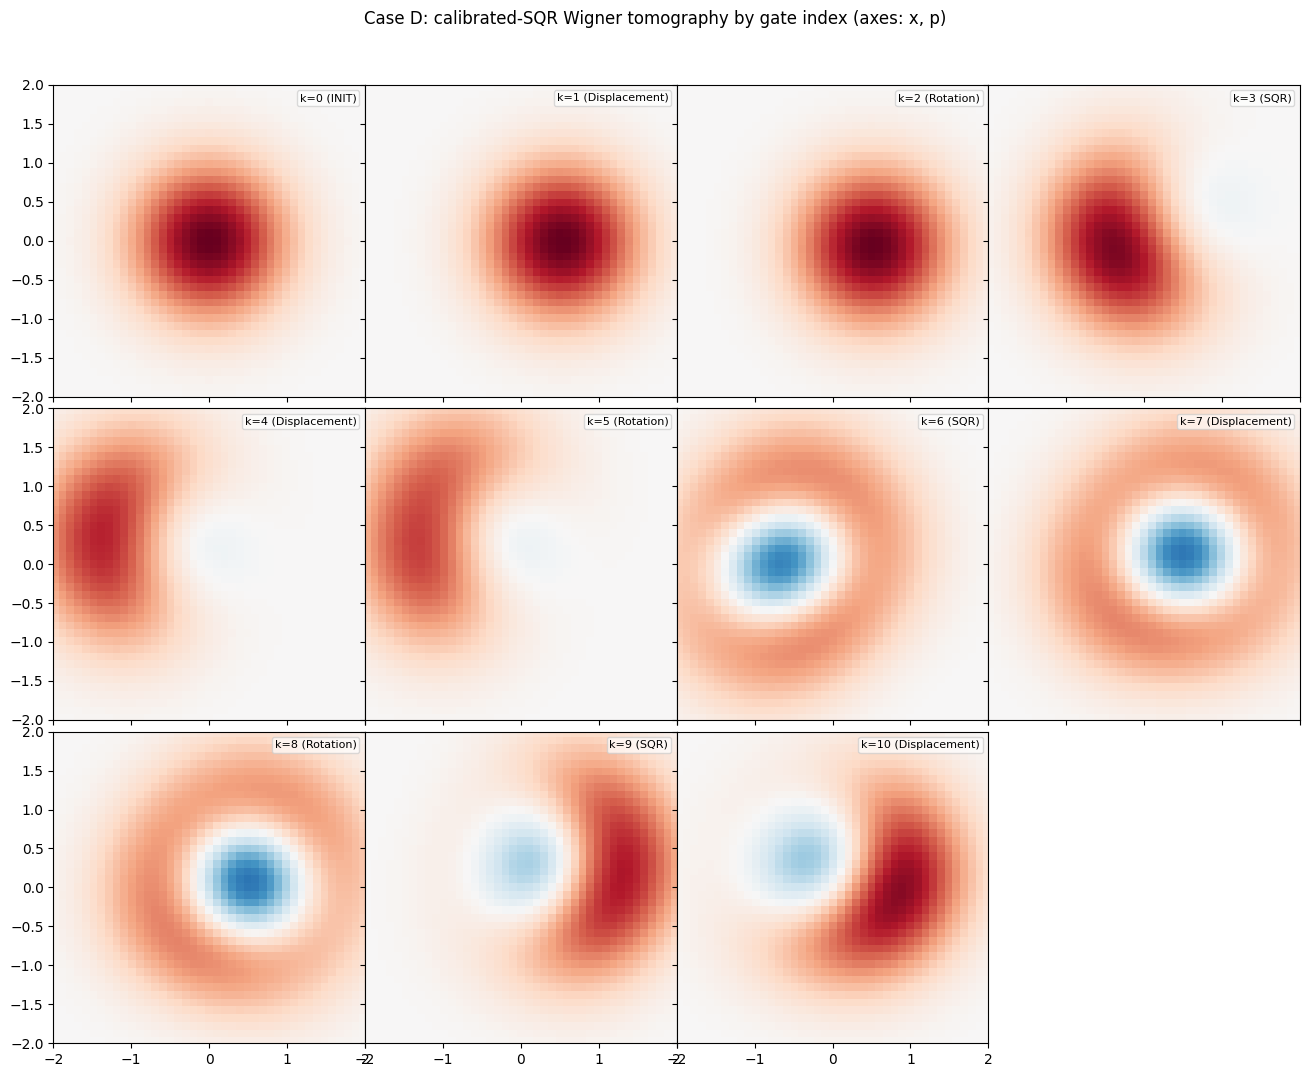

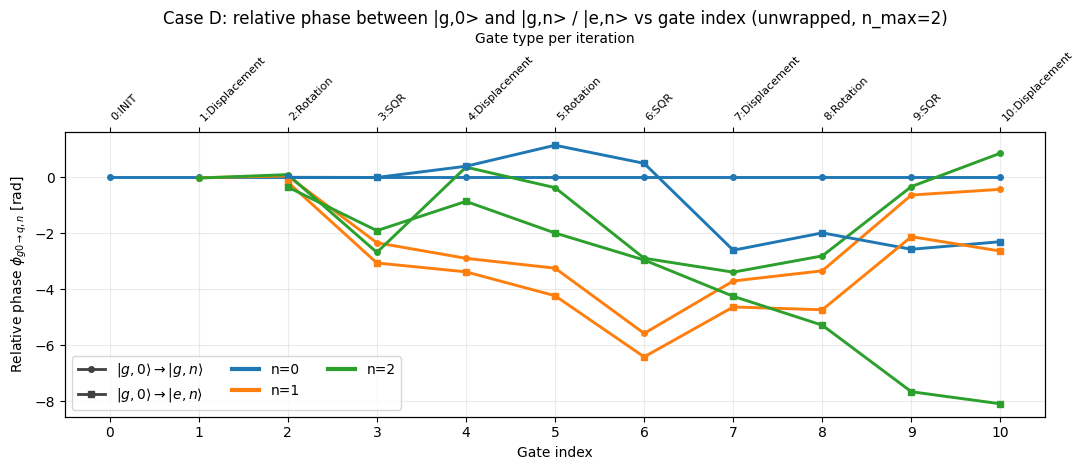

In [8]:
CASE_D = run_case_d(GATES, CONFIG, case_label="Case D")

print("Case D diagnostics:")
print(
    {
        "solver": CASE_D["metadata"]["solver"],
        "final_x": CASE_D["x"][-1],
        "final_y": CASE_D["y"][-1],
        "final_z": CASE_D["z"][-1],
        "final_n": CASE_D["n"][-1],
        "n_calibrated_sqr_gates": len(CASE_D["metadata"].get("calibration_results", {})),
    }
)
print("Case D gate-to-pulse mapping:")
print_mapping_rows(CASE_D)
print("Case D calibration summaries:")
for name, summary in CASE_D["metadata"].get("calibration_summaries", {}).items():
    print(name, summary)

plot_bloch_track(CASE_D, title="Case D: calibrated-SQR pulse-level Bloch trajectory", label_stride=int(CONFIG["top_axis_label_stride"]))
plt.show()

plot_wigner_grid(CASE_D, title="Case D: calibrated-SQR Wigner tomography by gate index", stride=int(CONFIG["wigner_stride"]), max_cols=int(CONFIG["wigner_max_cols"]))
plt.show()

plot_relative_phase_track(
    CASE_D,
    max_n=int(CONFIG["phase_track_max_n"]),
    threshold=float(CONFIG["phase_reference_threshold"]),
    unwrap=bool(CONFIG["phase_unwrap"]),
    label_stride=int(CONFIG["top_axis_label_stride"]),
)
plt.show()


## Section Y: Gate-Indexed Diagnostics and Pulse-Level Trajectories


{'overlay_cases': ['Case B', 'Case C', 'Case D'], 'n_max': 2, 'selected_gate_index': 3, 'selected_gate_type': 'SQR', 'selected_gate_name': 'SQR_527e17733de113ecaead4876b2bcafeb'}
Case A relative-phase debug at gate index 3:
  basis ordering: |n>_cavity tensor |q>_qubit = qt.tensor(cavity, qubit)
  reference: |g,0> targets: |g,n> and |e,n>
  c_g0 = (0.658167683098599+0j)
  c_g0 = (0.658167683098599+0j) | coherence=<g,0|rho|g,0>=(0.43318469907537777+0j) | phi_g=0.0 | plotted_phi_g=0.0
  c_e0 = (0.6566627857226666-0.002496116851066249j) | coherence=<e,0|rho|g,0>=(0.4321942242561592-0.0016428634446096439j) | phi_e=-0.0038011973315842966 | plotted_phi_e=-0.0038011973315842966
  c_g1 = (-0.15867955605509576+0.003754360379057217j) | coherence=<g,1|rho|g,0>=(-0.10443775576389663+0.0024709986722012663j) | phi_g=3.1179370539103717 | plotted_phi_g=3.1179370539103717
  c_e1 = (-0.3173651949146561+0.006979711110192676j) | coherence=<e,1|rho|g,0>=(-0.20887951503311444+0.0045938202900930635j) | phi_e

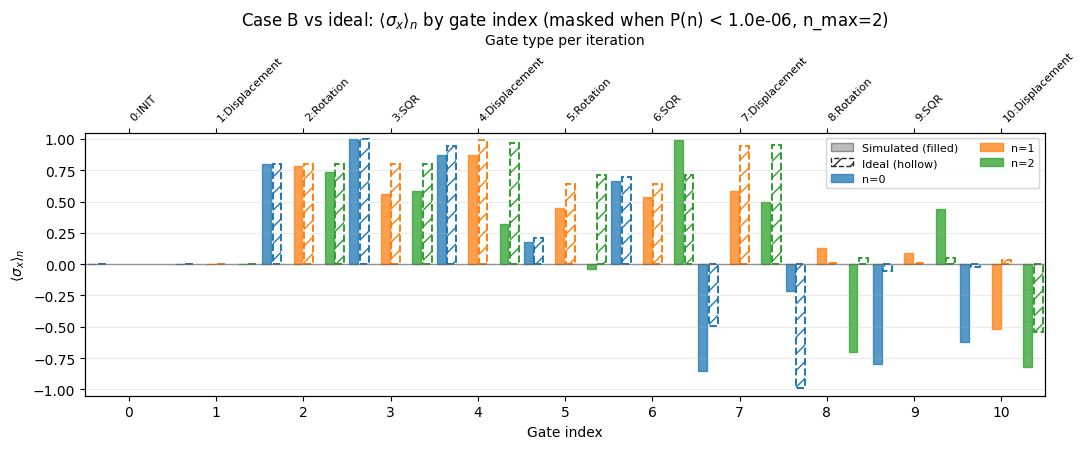

Saved: outputs\figures\case_b_bloch_Y_grouped_bars.png


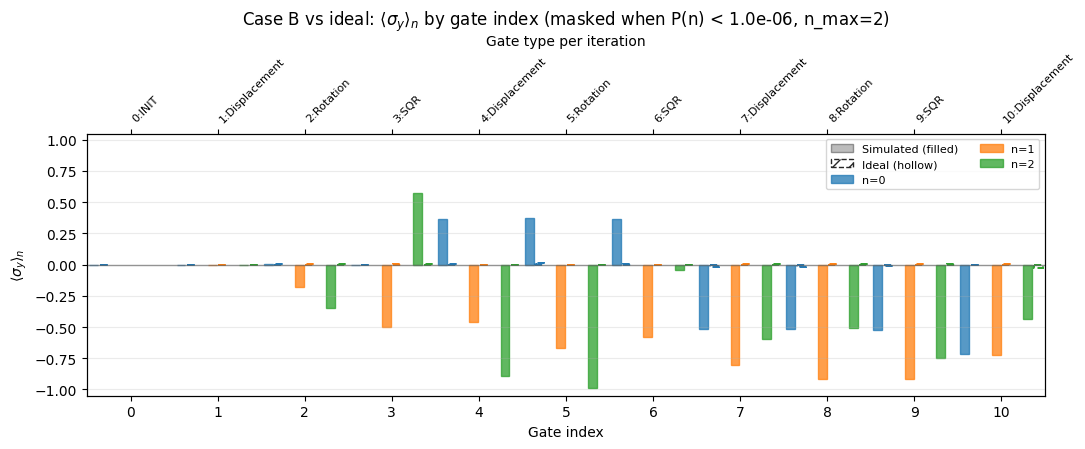

Saved: outputs\figures\case_b_bloch_Z_grouped_bars.png


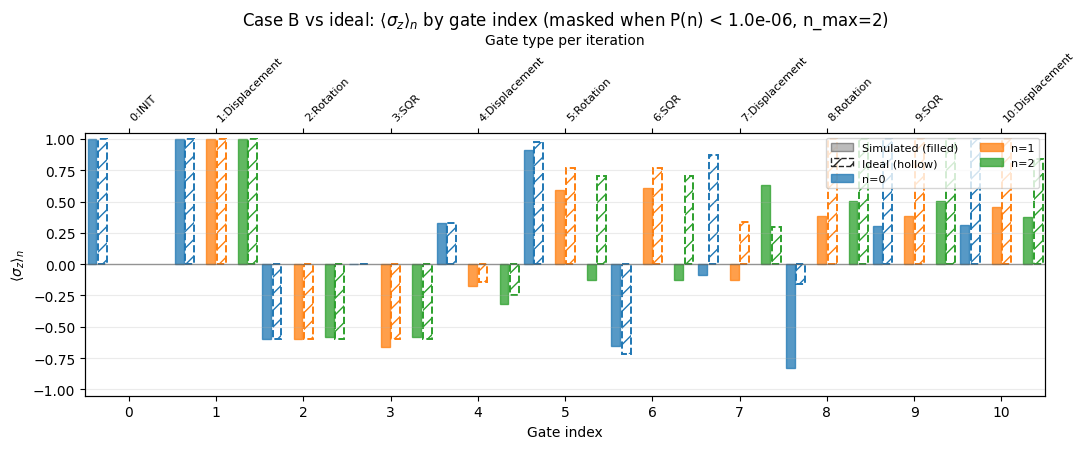

Saved: outputs\figures\case_b_relative_phase_vs_gate_index.png


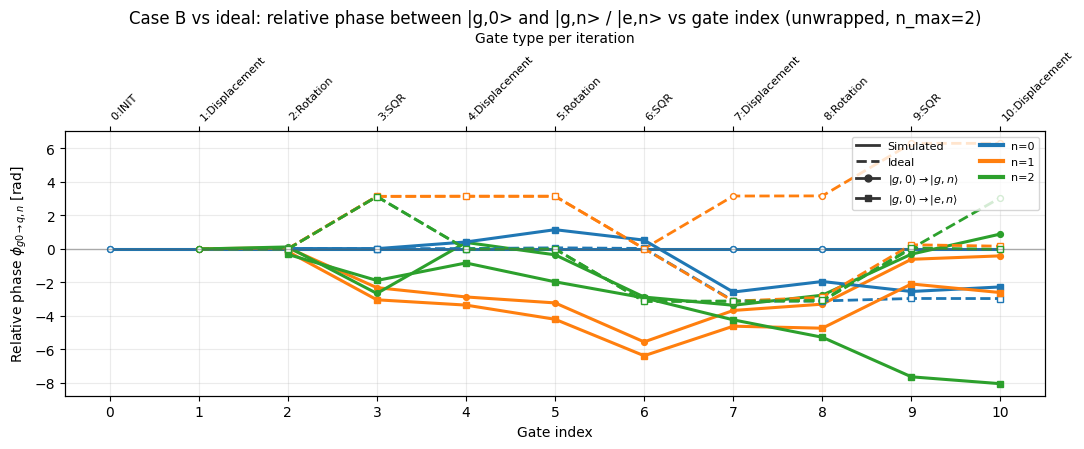

Saved: outputs\figures\case_b_phase_error_vs_gate_index.png


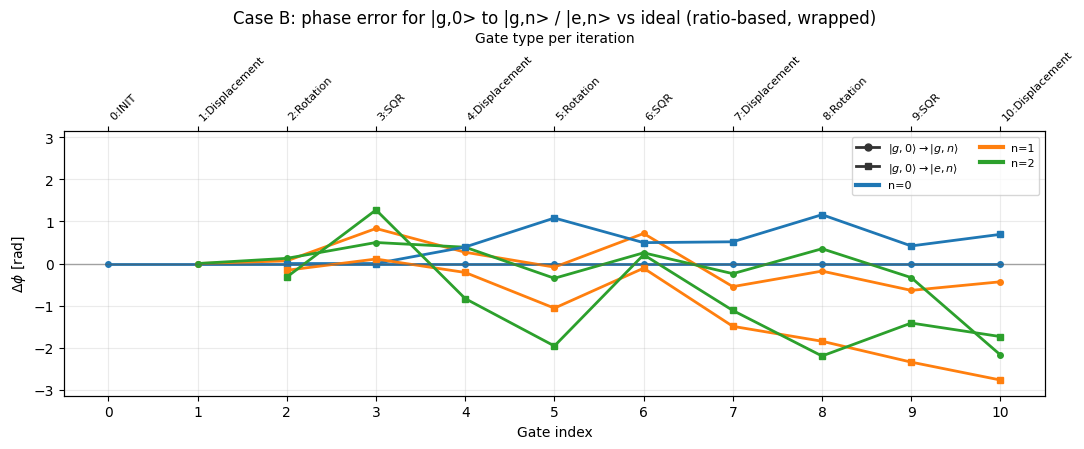

Saved: outputs\figures\case_b_bloch_trajectory_gate_3_sim_ideal.png


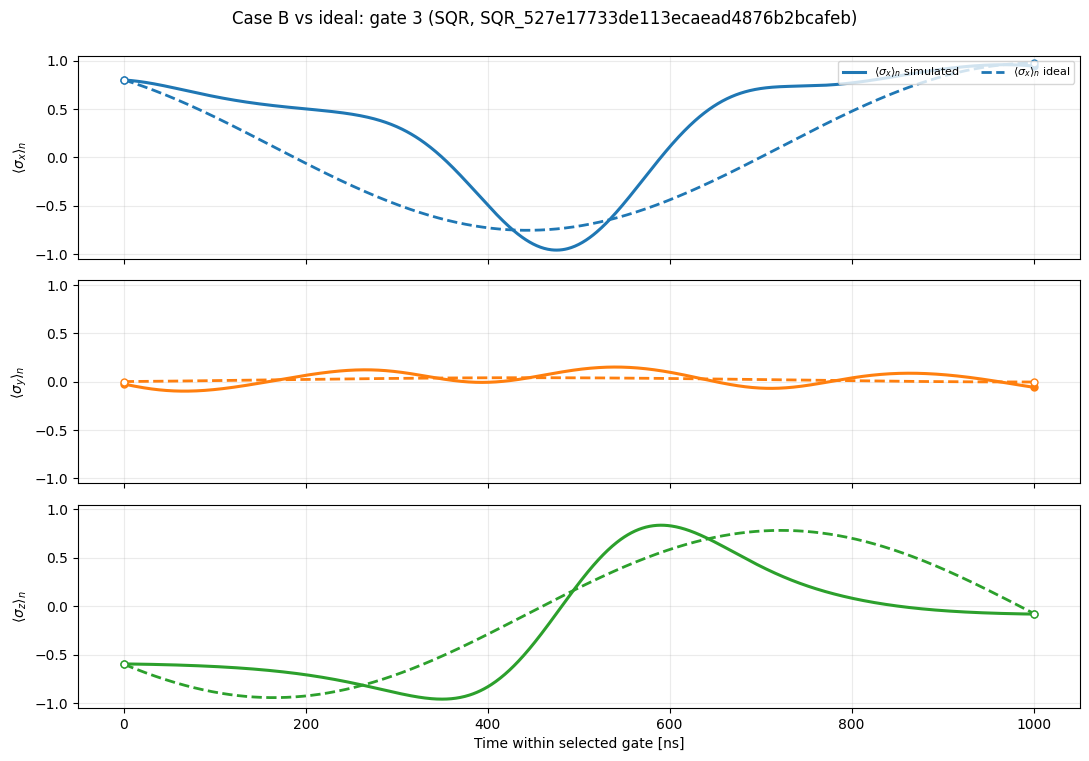

Saved: outputs\figures\case_b_bloch_trajectory_error_gate_3.png


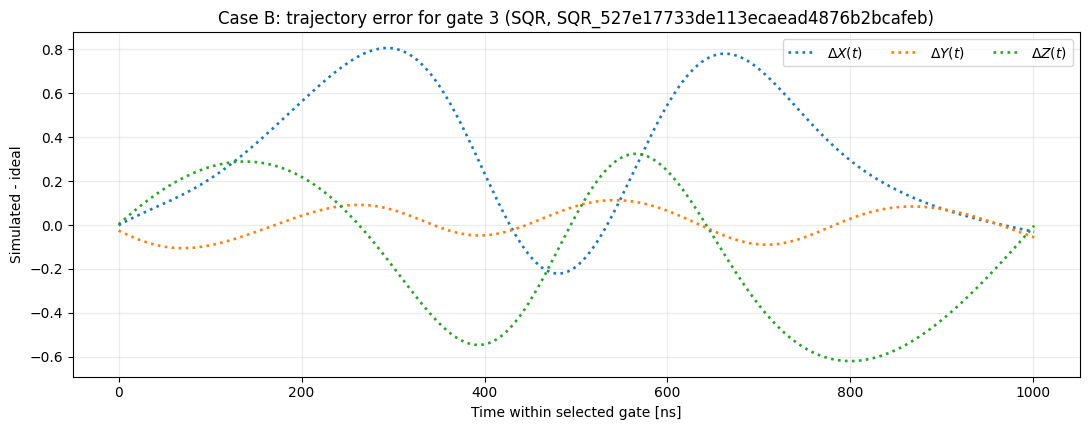

Overlay diagnostics for Case C:
Case C relative-phase debug at gate index 3:
  basis ordering: |n>_cavity tensor |q>_qubit = qt.tensor(cavity, qubit)
  reference: |g,0> targets: |g,n> and |e,n>
  c_g0 = (0.6615835428025899+0j)
  c_g0 = (0.6615835428025899+3.909675926946853e-18j) | coherence=<g,0|rho|g,0>=(0.43769278410722634+2.5865772509594988e-18j) | phi_g=5.909572524105942e-18 | plotted_phi_g=5.909572524105942e-18
  c_e0 = (0.6459814369338598-0.0024387767978733283j) | coherence=<e,0|rho|g,0>=(0.42737068763141073-0.0016134545940417922j) | phi_e=-0.0037752868301905037 | plotted_phi_e=-0.0037752868301905037
  c_g1 = (-0.09912359000021037-0.10349512074728713j) | coherence=<g,1|rho|g,0>=(-0.06557853584765055-0.06847066864677205j) | phi_g=-2.3346226786712814 | plotted_phi_g=-2.3346226786712814
  c_e1 = (-0.31391840973902474-0.02693317375290558j) | coherence=<e,1|rho|g,0>=(-0.20768325366609902-0.017818544510365j) | phi_e=-3.0560055152488506 | plotted_phi_e=-3.0560055152488506
  c_g2 = (-0.0

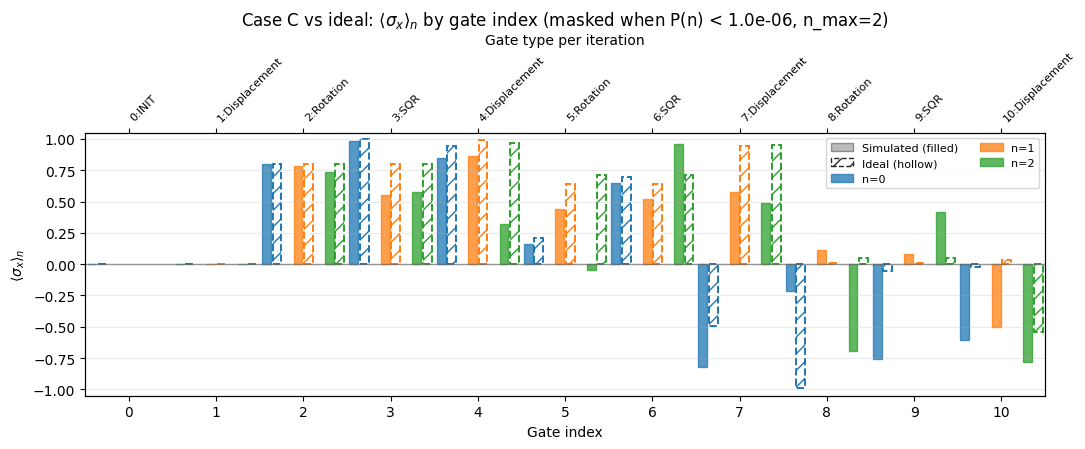

Saved: outputs\figures\case_c_bloch_Y_grouped_bars.png


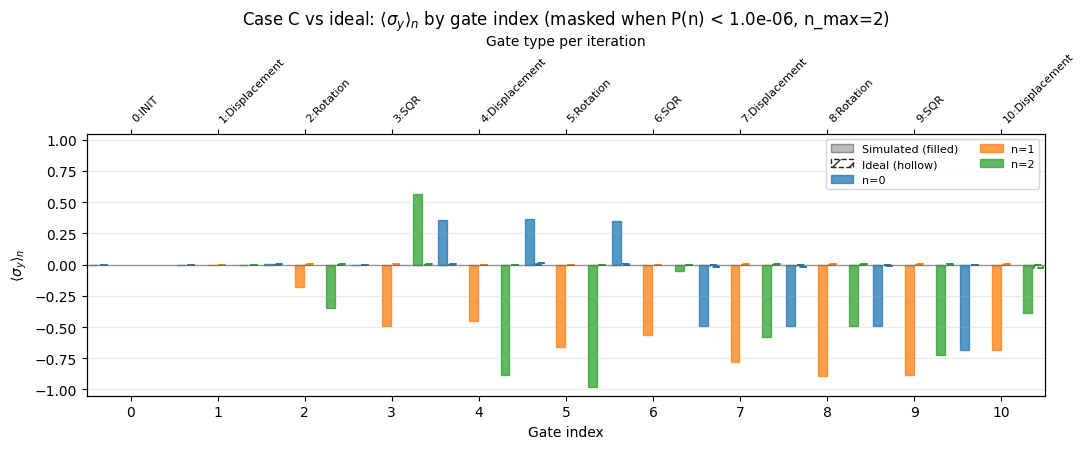

Saved: outputs\figures\case_c_bloch_Z_grouped_bars.png


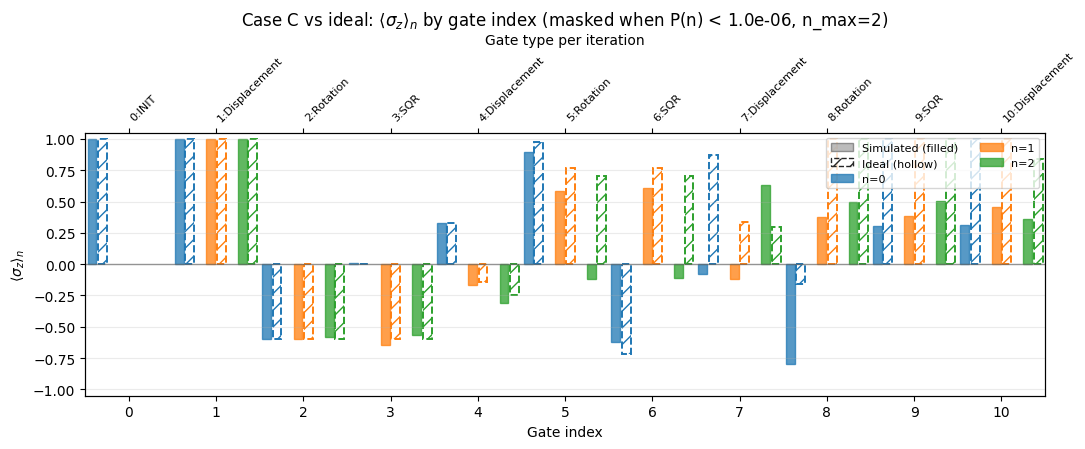

Saved: outputs\figures\case_c_relative_phase_vs_gate_index.png


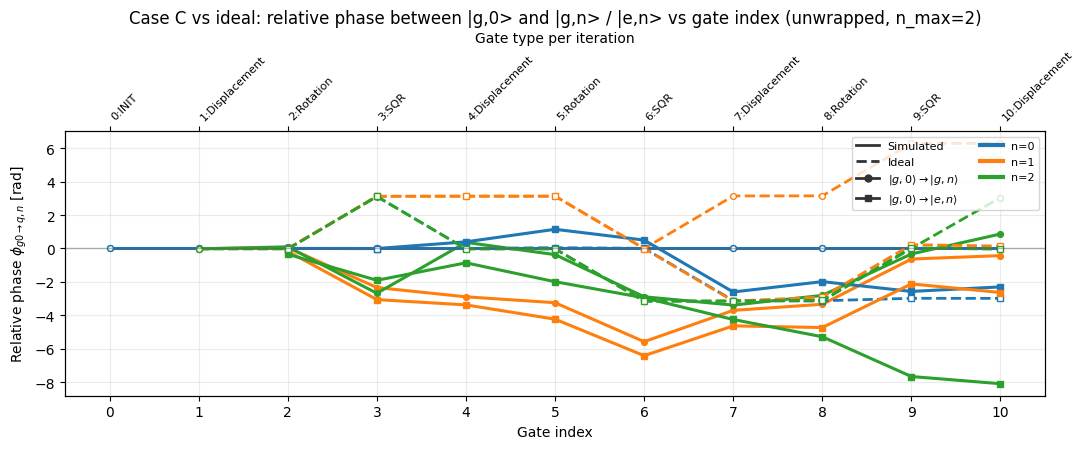

Saved: outputs\figures\case_c_phase_error_vs_gate_index.png


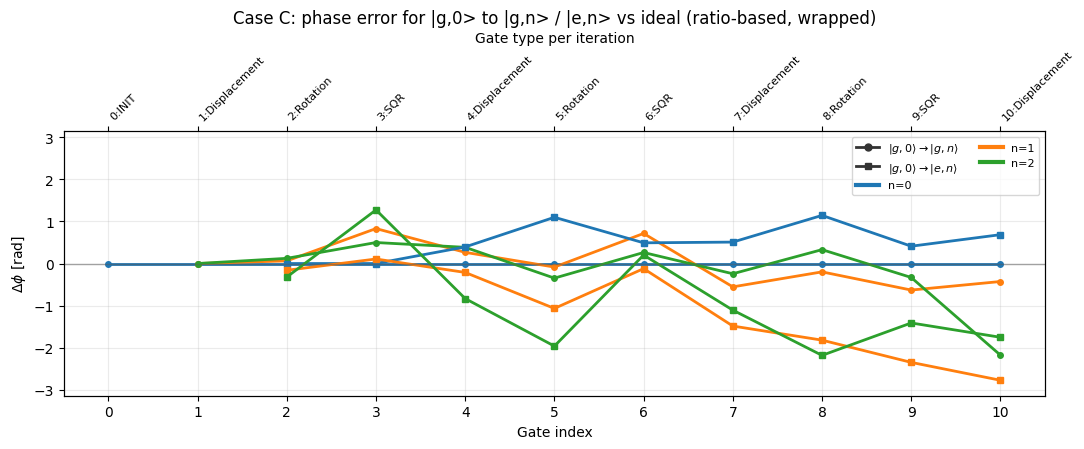

Saved: outputs\figures\case_c_bloch_trajectory_gate_3_sim_ideal.png


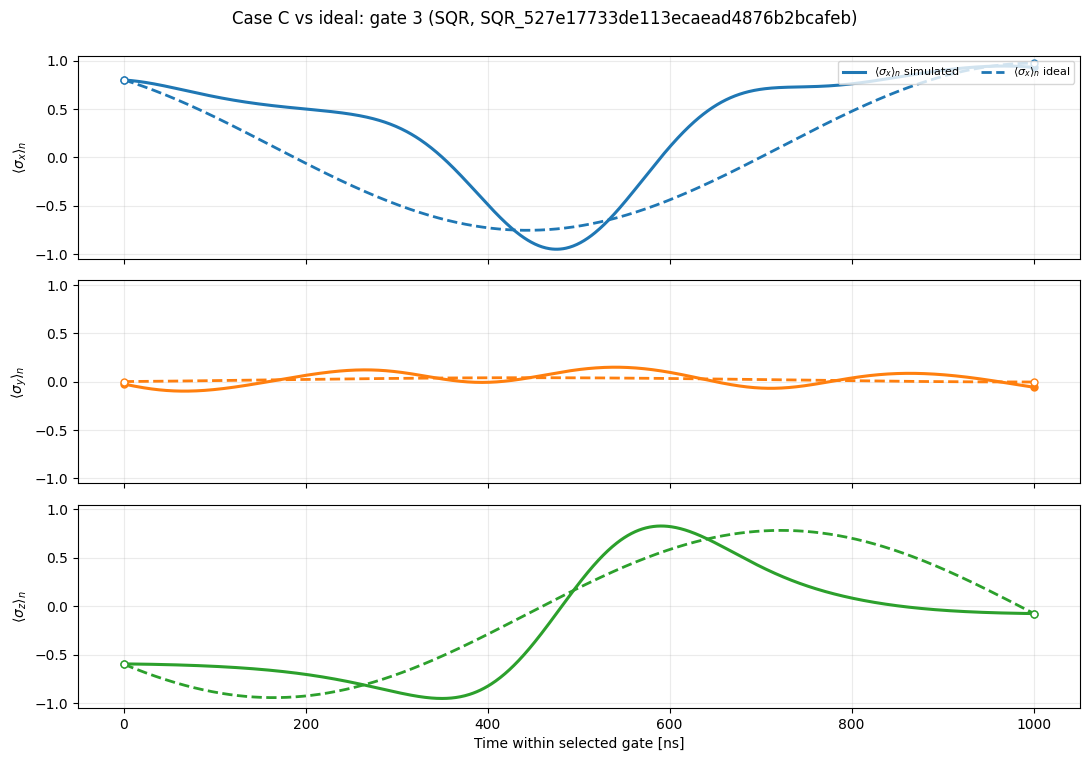

Saved: outputs\figures\case_c_bloch_trajectory_error_gate_3.png


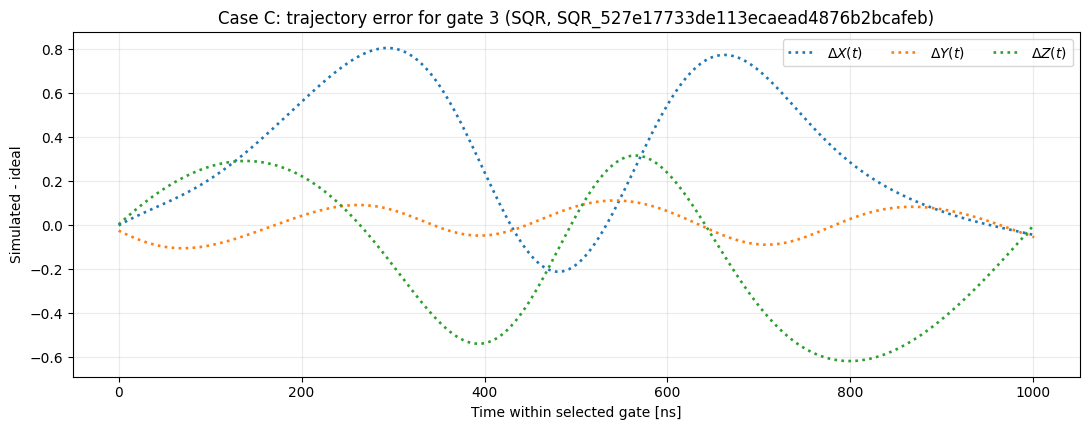

Overlay diagnostics for Case D:
Case D relative-phase debug at gate index 3:
  basis ordering: |n>_cavity tensor |q>_qubit = qt.tensor(cavity, qubit)
  reference: |g,0> targets: |g,n> and |e,n>
  c_g0 = (0.6615837191830203+0j)
  c_g0 = (0.6615837191830203-3.4181200785079192e-19j) | coherence=<g,0|rho|g,0>=(0.4376930174880374-2.2613725941534265e-19j) | phi_g=-5.166572240817692e-19 | plotted_phi_g=-5.166572240817692e-19
  c_e0 = (0.6459812604829254-0.0024393650573846016j) | coherence=<e,0|rho|g,0>=(0.42737068483282914-0.0016138442071096063j) | phi_e=-0.0037761984932797163 | plotted_phi_e=-0.0037761984932797167
  c_g1 = (-0.09912365828291625-0.10349504636556728j) | coherence=<g,1|rho|g,0>=(-0.06557859850583853-0.06847063769155112j) | phi_g=-2.3346233817975035 | plotted_phi_g=-2.3346233817975035
  c_e1 = (-0.3139184282420892-0.026933015925962863j) | coherence=<e,1|rho|g,0>=(-0.20768332127648945-0.017818444845114027j) | phi_e=-3.0560060193593146 | plotted_phi_e=-3.0560060193593146
  c_g2 = 

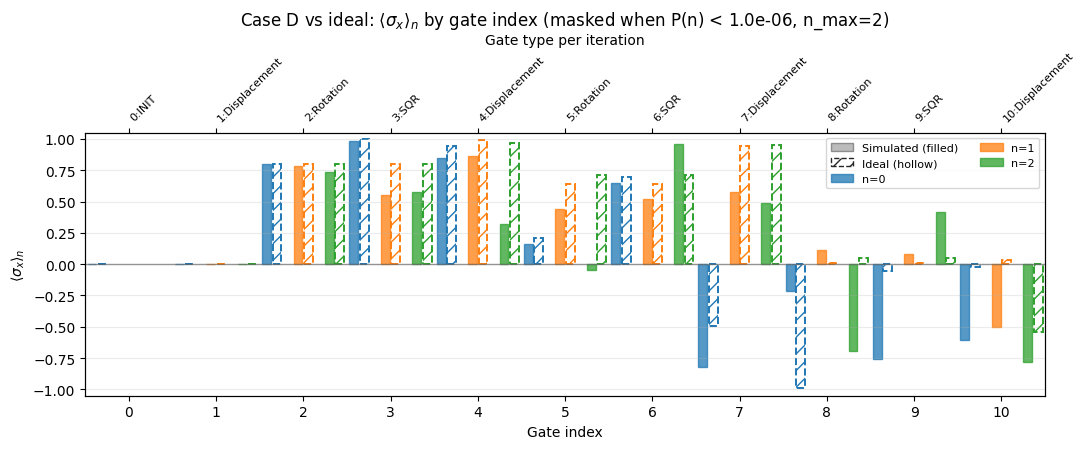

Saved: outputs\figures\case_d_bloch_Y_grouped_bars.png
Saved: outputs\figures\bloch_Y_grouped_bars.png


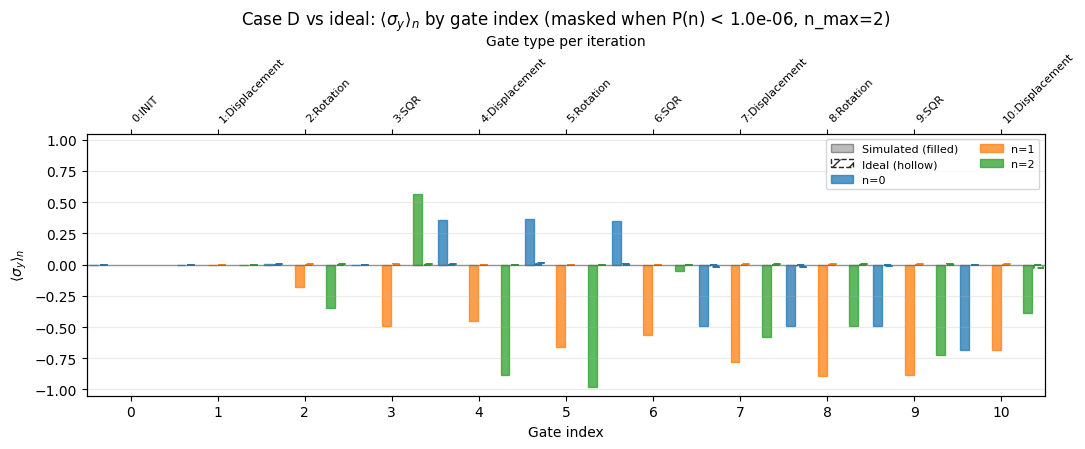

Saved: outputs\figures\case_d_bloch_Z_grouped_bars.png
Saved: outputs\figures\bloch_Z_grouped_bars.png


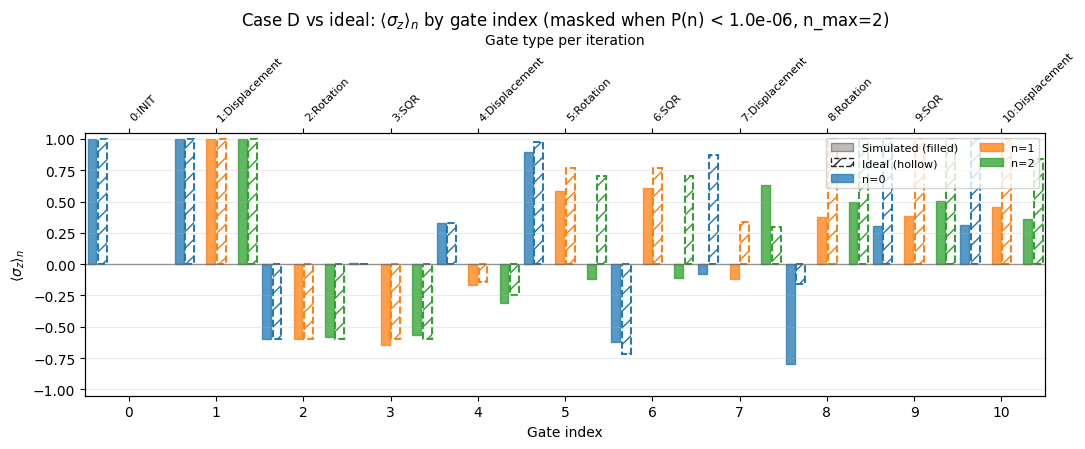

Saved: outputs\figures\case_d_relative_phase_vs_gate_index.png
Saved: outputs\figures\relative_phase_vs_gate_index.png


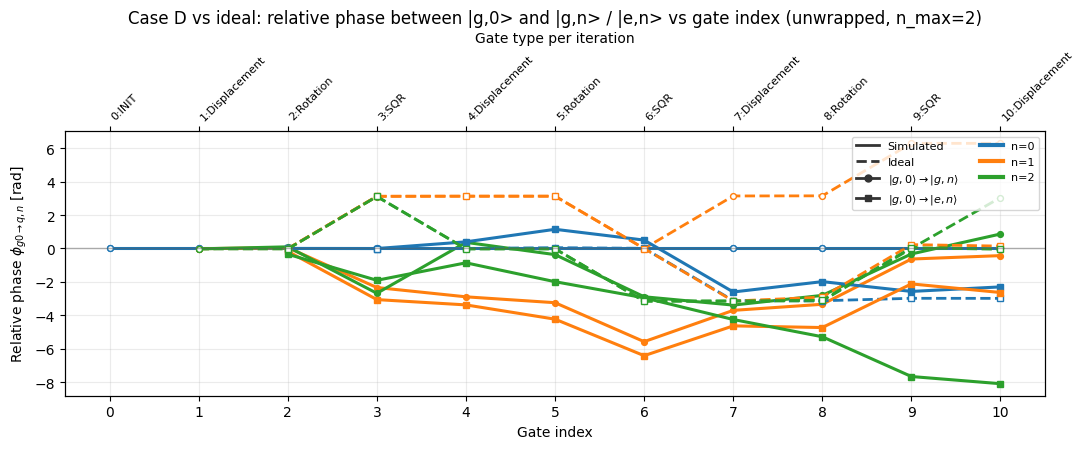

Saved: outputs\figures\case_d_phase_error_vs_gate_index.png
Saved: outputs\figures\phase_error_vs_gate_index.png


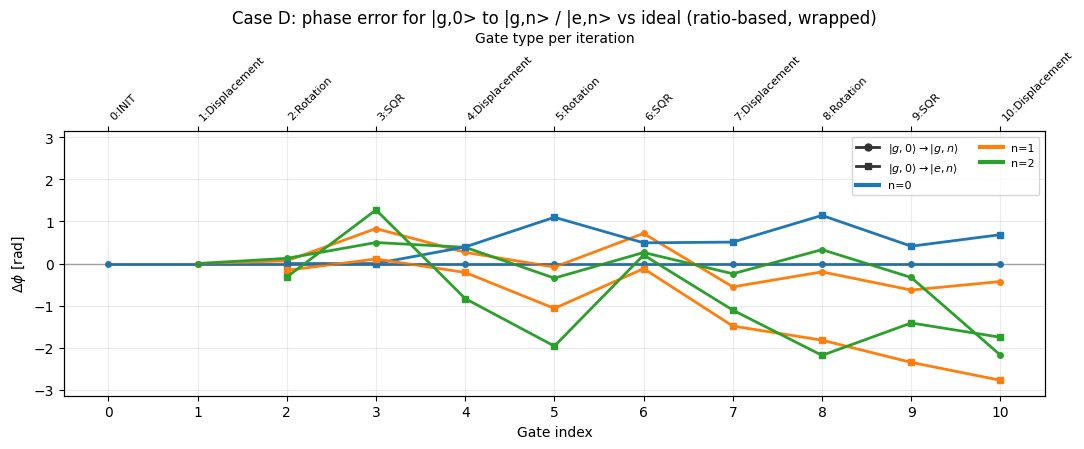

Saved: outputs\figures\case_d_bloch_trajectory_gate_3_sim_ideal.png
Saved: outputs\figures\bloch_trajectory_gate_3_sim_ideal.png


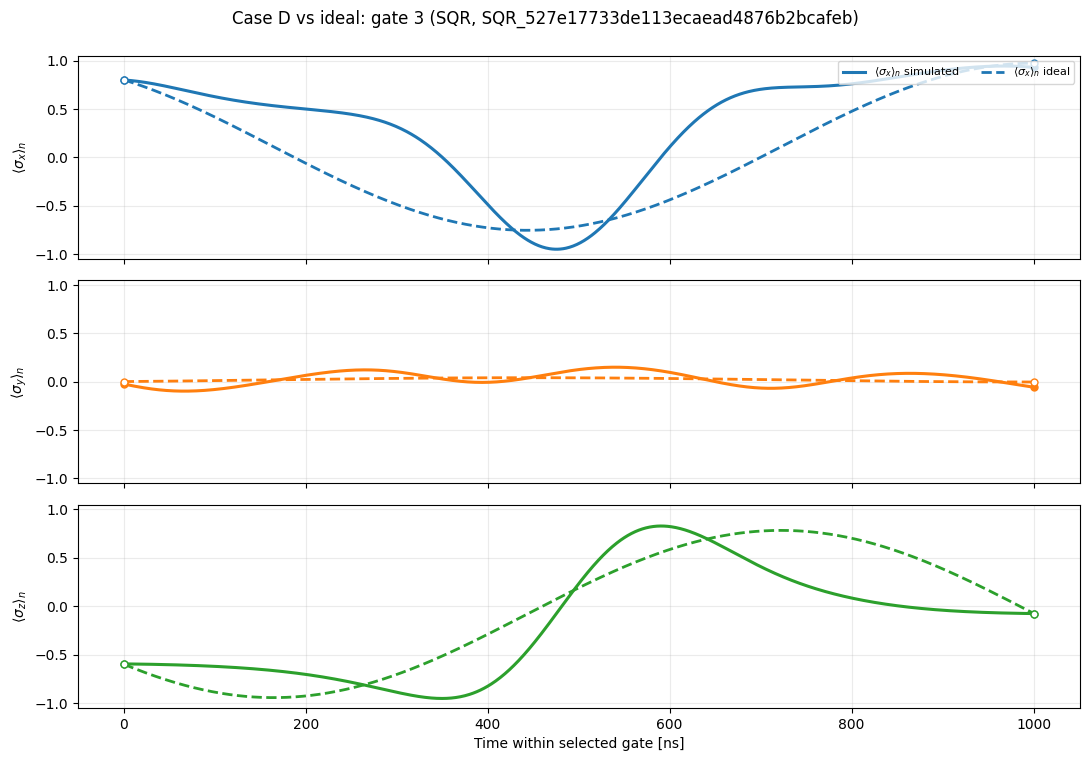

Saved: outputs\figures\case_d_bloch_trajectory_error_gate_3.png
Saved: outputs\figures\bloch_trajectory_error_gate_3.png


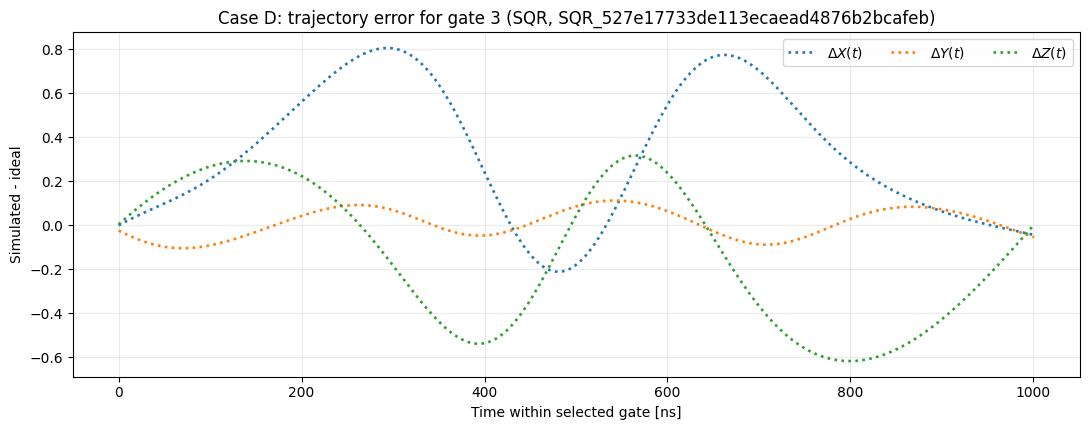

In [9]:
TRACKS = {
    "Case A": CASE_A,
    "Case B": CASE_B,
    "Case C": CASE_C,
    "Case D": CASE_D,
}
overlay_case_names = [str(name) for name in CONFIG["overlay_cases"]]
for name in overlay_case_names:
    if name not in {"Case B", "Case C", "Case D"}:
        raise KeyError(f"Unsupported overlay case '{name}'. Expected Case B/Case C/Case D.")

diagnostic_max_n = int(CONFIG["phase_track_max_n"])
probability_threshold = float(CONFIG["gate_diag_probability_threshold"])
label_stride = int(CONFIG["top_axis_label_stride"])
output_dir = Path(CONFIG["output_figure_dir"])
ideal_bloch = fock_resolved_bloch_diagnostics(CASE_A, max_n=diagnostic_max_n, probability_threshold=probability_threshold)
ideal_phase = relative_phase_family_diagnostics(
    CASE_A,
    max_n=diagnostic_max_n,
    probability_threshold=probability_threshold,
    unwrap=bool(CONFIG["phase_unwrap"]),
    coherence_threshold=probability_threshold,
)

if CONFIG["trajectory_gate_index"] is None:
    selected_gate_index = next((idx for idx, gate in enumerate(GATES, start=1) if gate.type == "SQR"), 1)
else:
    selected_gate_index = int(CONFIG["trajectory_gate_index"])

conditioned_cap = min(int(CONFIG["trajectory_conditioned_max_n"]), diagnostic_max_n)
conditioned_levels = list(range(conditioned_cap + 1))

print(
    {
        "overlay_cases": overlay_case_names,
        "n_max": diagnostic_max_n,
        "selected_gate_index": selected_gate_index,
        "selected_gate_type": GATES[selected_gate_index - 1].type,
        "selected_gate_name": GATES[selected_gate_index - 1].name,
    }
)

def _print_phase_debug(case_name, diagnostics, track):
    debug_snapshot = track["snapshots"][selected_gate_index]
    debug = relative_phase_debug_values(
        debug_snapshot["state"],
        max_n=diagnostic_max_n,
        probability_threshold=probability_threshold,
        coherence_threshold=probability_threshold,
    )
    print(f"{case_name} relative-phase debug at gate index {selected_gate_index}:")
    print("  basis ordering:", debug["basis_ordering"])
    print(
        "  reference:",
        debug["reference_label"],
        "targets:",
        debug["ground_target_template"],
        "and",
        debug["excited_target_template"],
    )
    print("  c_g0 =", debug["c_g0_gauge"])
    for row_idx, row in enumerate(debug["levels"]):
        plotted_ground = diagnostics["families"]["ground"]["phase"][row_idx, selected_gate_index]
        plotted_excited = diagnostics["families"]["excited"]["phase"][row_idx, selected_gate_index]
        print(
            f"  c_g{row['n']} = {row['c_gn_gauge']} | "
            f"coherence=<g,{row['n']}|rho|g,0>={row['coherence_gn_g0']} | "
            f"phi_g={row['ground_phase_rad']} | plotted_phi_g={plotted_ground}"
        )
        print(
            f"  c_e{row['n']} = {row['c_en_gauge']} | "
            f"coherence=<e,{row['n']}|rho|g,0>={row['coherence_en_g0']} | "
            f"phi_e={row['excited_phase_rad']} | plotted_phi_e={plotted_excited}"
        )
        if np.isfinite(row["ground_phase_rad"]) != np.isfinite(plotted_ground):
            raise AssertionError(f"{case_name} ground-family phase masking mismatch at n={row['n']}.")
        if np.isfinite(row["ground_phase_rad"]) and np.isfinite(plotted_ground):
            wrapped = (float(plotted_ground) - float(row["ground_phase_rad"]) + np.pi) % (2.0 * np.pi) - np.pi
            if abs(wrapped) > 1.0e-10:
                raise AssertionError(f"{case_name} plotted phase does not match extracted |g,0> -> |g,{row['n']}| phase.")
        if np.isfinite(row["excited_phase_rad"]) != np.isfinite(plotted_excited):
            raise AssertionError(f"{case_name} excited-family phase masking mismatch at n={row['n']}.")
        if np.isfinite(row["excited_phase_rad"]) and np.isfinite(plotted_excited):
            wrapped = (float(plotted_excited) - float(row["excited_phase_rad"]) + np.pi) % (2.0 * np.pi) - np.pi
            if abs(wrapped) > 1.0e-10:
                raise AssertionError(f"{case_name} plotted phase does not match extracted |g,0> -> |e,{row['n']}| phase.")

_print_phase_debug("Case A", ideal_phase, CASE_A)

OVERLAY_RESULTS = {}
for case_name in overlay_case_names:
    track = TRACKS[case_name]
    case_slug = case_name.lower().replace(" ", "_")
    sim_bloch = fock_resolved_bloch_diagnostics(track, max_n=diagnostic_max_n, probability_threshold=probability_threshold)
    sim_phase = relative_phase_family_diagnostics(
        track,
        max_n=diagnostic_max_n,
        probability_threshold=probability_threshold,
        unwrap=bool(CONFIG["phase_unwrap"]),
        coherence_threshold=probability_threshold,
    )
    sim_traj = simulate_gate_bloch_trajectory(
        track,
        GATES,
        CONFIG,
        gate_index=selected_gate_index,
        conditioned_n_levels=conditioned_levels,
        probability_threshold=probability_threshold,
    )
    ideal_traj = ideal_gate_bloch_trajectory(
        CASE_A,
        GATES,
        CONFIG,
        gate_index=selected_gate_index,
        times_s=sim_traj["times_s"],
        conditioned_n_levels=conditioned_levels,
        probability_threshold=probability_threshold,
    )
    OVERLAY_RESULTS[case_name] = {
        "bloch": sim_bloch,
        "phase": sim_phase,
        "trajectory": sim_traj,
        "ideal_trajectory": ideal_traj,
    }

    print(f"Overlay diagnostics for {case_name}:")
    _print_phase_debug(case_name, sim_phase, track)
    for component in ("x", "y", "z"):
        fig = plot_fock_resolved_bloch_grouped_bars(sim_bloch, ideal_bloch, track, component=component, label_stride=label_stride)
        if bool(CONFIG["save_output_figures"]):
            target = f"{case_slug}_bloch_{component.upper()}_grouped_bars.png"
            print("Saved:", save_figure(fig, output_dir, target, dpi=int(CONFIG["output_figure_dpi"])))
            if case_name == "Case D":
                generic = f"bloch_{component.upper()}_grouped_bars.png"
                print("Saved:", save_figure(fig, output_dir, generic, dpi=int(CONFIG["output_figure_dpi"])))
        plt.show()
        plt.close(fig)

    fig = plot_phase_overlay_lines(sim_phase, ideal_phase, track, label_stride=label_stride)
    if bool(CONFIG["save_output_figures"]):
        print("Saved:", save_figure(fig, output_dir, f"{case_slug}_relative_phase_vs_gate_index.png", dpi=int(CONFIG["output_figure_dpi"])))
        if case_name == "Case D":
            print("Saved:", save_figure(fig, output_dir, "relative_phase_vs_gate_index.png", dpi=int(CONFIG["output_figure_dpi"])))
    plt.show()
    plt.close(fig)

    fig = plot_phase_error_track(sim_phase, ideal_phase, track, label_stride=label_stride)
    if bool(CONFIG["save_output_figures"]):
        print("Saved:", save_figure(fig, output_dir, f"{case_slug}_phase_error_vs_gate_index.png", dpi=int(CONFIG["output_figure_dpi"])))
        if case_name == "Case D":
            print("Saved:", save_figure(fig, output_dir, "phase_error_vs_gate_index.png", dpi=int(CONFIG["output_figure_dpi"])))
    plt.show()
    plt.close(fig)

    fig = plot_gate_bloch_trajectory_overlay(sim_traj, ideal_traj)
    if bool(CONFIG["save_output_figures"]):
        target = f"{case_slug}_bloch_trajectory_gate_{selected_gate_index}_sim_ideal.png"
        print("Saved:", save_figure(fig, output_dir, target, dpi=int(CONFIG["output_figure_dpi"])))
        if case_name == "Case D":
            generic = f"bloch_trajectory_gate_{selected_gate_index}_sim_ideal.png"
            print("Saved:", save_figure(fig, output_dir, generic, dpi=int(CONFIG["output_figure_dpi"])))
    plt.show()
    plt.close(fig)

    fig = plot_gate_bloch_trajectory_error(sim_traj, ideal_traj)
    if bool(CONFIG["save_output_figures"]):
        target = f"{case_slug}_bloch_trajectory_error_gate_{selected_gate_index}.png"
        print("Saved:", save_figure(fig, output_dir, target, dpi=int(CONFIG["output_figure_dpi"])))
        if case_name == "Case D":
            generic = f"bloch_trajectory_error_gate_{selected_gate_index}.png"
            print("Saved:", save_figure(fig, output_dir, generic, dpi=int(CONFIG["output_figure_dpi"])))
    plt.show()
    plt.close(fig)


## Section 8: Weakness Metrics and Comparison Plots

Definitions used here:

- **Wigner negativity**: `0.5 * (integral |W| dx dp - 1)`.
- **Fidelity-based weakness**: `1 - F(rho_case, rho_A)` referenced to Case A at the same gate index.


e:\Program Files\Python311\Lib\site-packages\qutip\core\data\expm.py:136: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  return Dense(scipy.linalg.sqrtm(matrix.as_ndarray()))


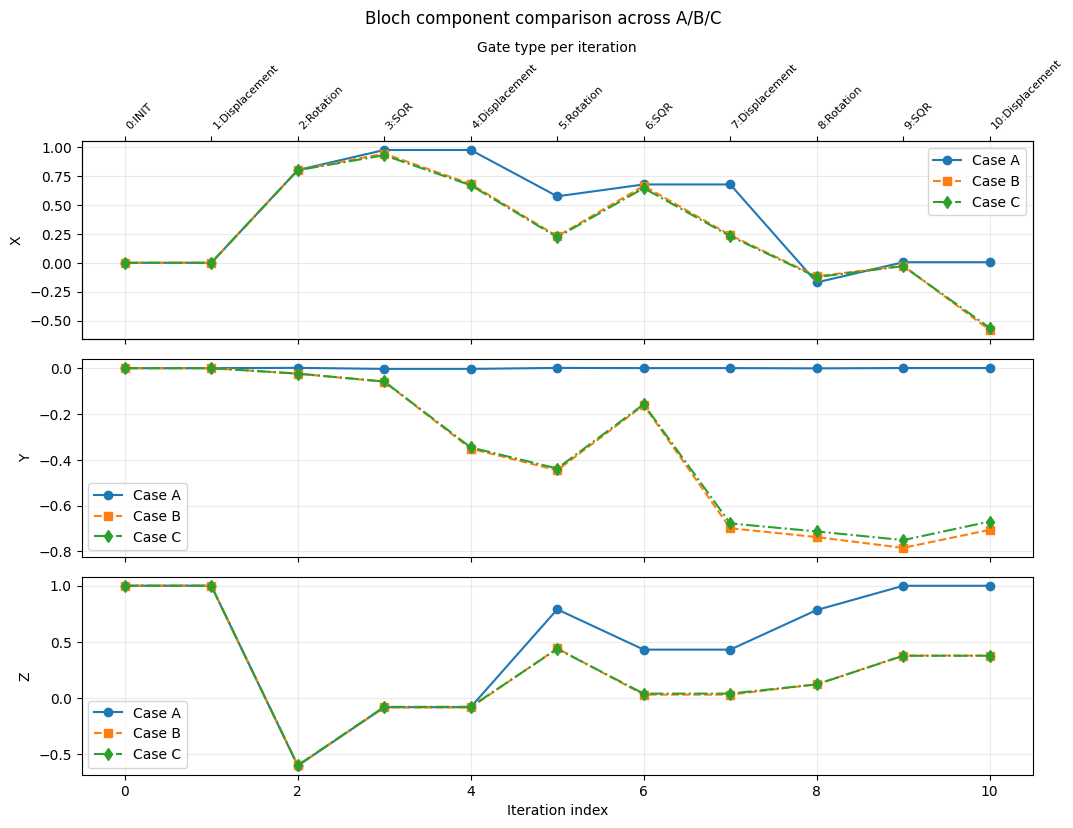

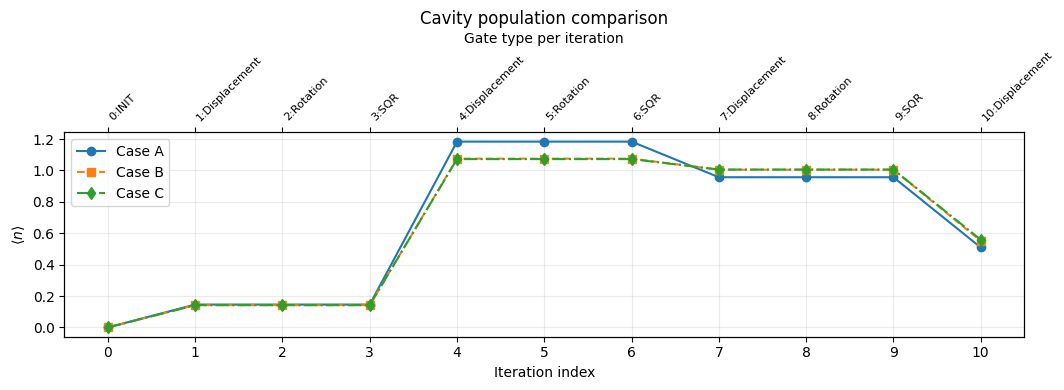

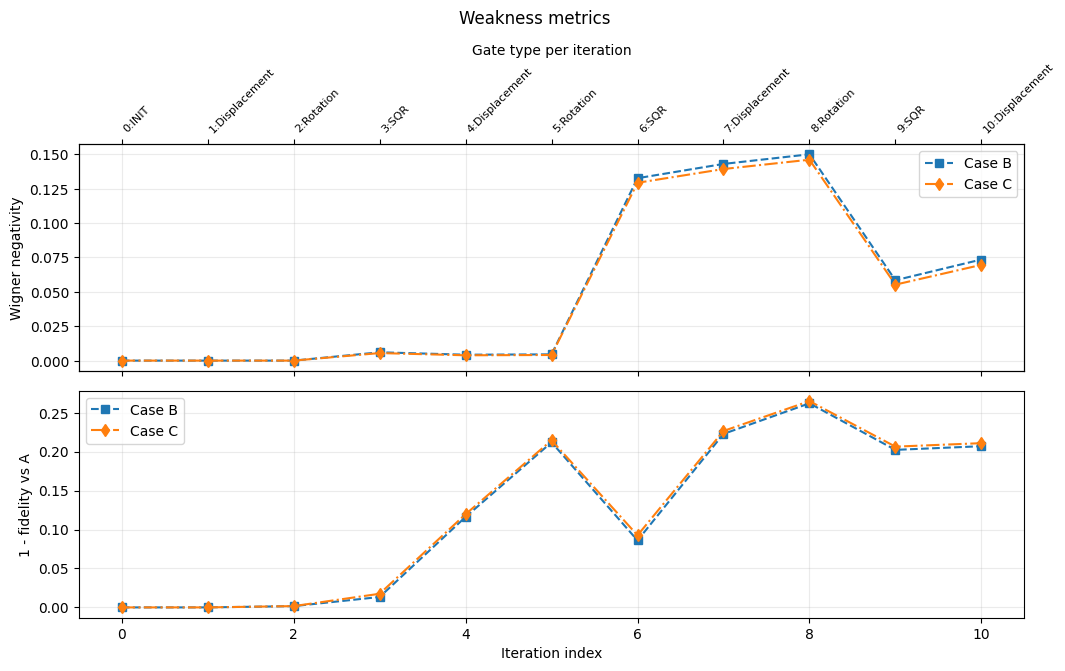

A vs B: {'x_rmse': 0.2598232424315618, 'y_rmse': 0.4763321213338379, 'z_rmse': 0.38679465442405536, 'n_rmse': 0.06318678767829654, 'final_fidelity': 0.793082101536135}
A vs C: {'x_rmse': 0.25979396967322665, 'y_rmse': 0.45899971524435496, 'z_rmse': 0.3861630788481993, 'n_rmse': 0.06527347347598401, 'final_fidelity': 0.7891775907473564}
A vs D: {'x_rmse': 0.25979336150514865, 'y_rmse': 0.45899795762359824, 'z_rmse': 0.3861612266679136, 'n_rmse': 0.0652719774320119, 'final_fidelity': 0.7891787007338413}
Example Case D calibration reduction: {'sqr_name': 'SQR_527e17733de113ecaead4876b2bcafeb', 'max_n': 2, 'improved_levels': [0], 'mean_initial_loss': 0.3138204276372694, 'mean_optimized_loss': 0.31382042763700874, 'mean_loss_reduction': 2.6068036618198676e-13}


In [11]:
CASE_A = attach_weakness_metrics(CASE_A, CASE_A)
CASE_B = attach_weakness_metrics(CASE_A, CASE_B)
CASE_C = attach_weakness_metrics(CASE_A, CASE_C)
CASE_D = attach_weakness_metrics(CASE_A, CASE_D)

plot_component_comparison(CASE_A, CASE_B, CASE_C, label_stride=int(CONFIG["top_axis_label_stride"]))
plt.show()

plot_cavity_population_comparison(CASE_A, CASE_B, CASE_C, label_stride=int(CONFIG["top_axis_label_stride"]))
plt.show()

plot_weakness(CASE_B, CASE_C, reference_track=CASE_A, label_stride=int(CONFIG["top_axis_label_stride"]))
plt.show()

COMPARISON_AB = comparison_metrics(CASE_A, CASE_B)
COMPARISON_AC = comparison_metrics(CASE_A, CASE_C)
COMPARISON_AD = comparison_metrics(CASE_A, CASE_D)
print("A vs B:", COMPARISON_AB)
print("A vs C:", COMPARISON_AC)
print("A vs D:", COMPARISON_AD)

if CASE_D["metadata"].get("calibration_summaries"):
    first_summary = next(iter(CASE_D["metadata"]["calibration_summaries"].values()))
    print("Example Case D calibration reduction:", first_summary)
